# 🐧🐧Tarea 2 --- IELE756 🐧🐧
**Equipo Pinguino conformado por** : Hellen Quiñones, Gustavo Sánchez

**Comunas Asignadas**: Alhue, La Pintana, Huechuraba, El Monte, María Pinto

**Fecha de entrega**: jueves 16 de abril de 2026

**Link al repositorio de GitHub**: https://github.com/hellenelizabethqm-netizen/iele756-region-XXXX

---

**Objetivo**

Construir un perfil de salud de las comunas que te fueron asignadas utilizando dos conjuntos de datos complementarios: ENO (vigilancia de enfermedades de notificación obligatoria, 2007–2024) y GRD (registros de egresos hospitalarios, 2022–2024). En la Tarea 0 demostraste que podías abrir e inspeccionar cada conjunto de datos; en la Tarea 1 construiste una línea base demográfica a partir del Censo. Ahora profundizarás en los datos de salud: limpiando variables categóricas desordenadas, calculando tasas, construyendo perfiles de enfermedades por nacionalidad y produciendo tablas resumen a nivel comunal que luego unirás con el resumen censal en la Tarea 3.

---

#### Cargamos las Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

---

### **Parte A: ENO – Enfermedades de Notificación Obligatoria (5 pts)**
### **🐧🐧A.0 Carga y limpieza de datos (1 pt) 🐧🐧**
Primero escogemos las columnas relevantes para esta tarea, con un total de 11 columnas y 333300 filas.


In [2]:
############################################################
### 🐧🐧**A.0.1 Cargar el conjunto de datos ENO**🐧🐧 ####
############################################################

# escoger solo las columnas relevantes para el análisis

eno_cols = ["ENO", "anho_notificacion", "region", "codigo_comuna_residencia",
            "nacionalidad", "sexo", "grupo_edad", "nombre_instruccion",
            "cie_10_diagnostico", "diagnostico", "pais_contagio"]

# cargar el conjunto de datos ENO con las columnas seleccionadas
eno = pd.read_csv("20241218_base_eno_final.csv",
                  sep=";", encoding="utf-8-sig", usecols=eno_cols)

print(eno.shape)
eno.info()


(333300, 11)
<class 'pandas.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   region                    333300 non-null  str  
 1   nacionalidad              333300 non-null  str  
 2   cie_10_diagnostico        333300 non-null  str  
 3   diagnostico               333300 non-null  str  
 4   anho_notificacion         333300 non-null  int64
 5   ENO                       333300 non-null  str  
 6   nombre_instruccion        333300 non-null  str  
 7   pais_contagio             333300 non-null  str  
 8   sexo                      333300 non-null  str  
 9   grupo_edad                333300 non-null  str  
 10  codigo_comuna_residencia  333300 non-null  str  
dtypes: int64(1), str(10)
memory usage: 65.4 MB


In [3]:
eno.head()

,region,nacionalidad,cie_10_diagnostico,diagnostico,anho_notificacion,ENO,nombre_instruccion,pais_contagio,sexo,grupo_edad,codigo_comuna_residencia
0,Región de Tarapacá,Extranjero,A97.0,DENGUE SIN DATOS DE ALARMA,2020,Arbovirus,Desconocido,Desconocido,mujer,25-29,01107
1,Región de Valparaíso,Desconocido,A90.X,FIEBRE DEL DENGUE,2018,Arbovirus,Desconocido,Desconocido,hombre,70-74,05301
2,Región de Valparaíso,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,2020,Arbovirus,Desconocido,Desconocido,mujer,70-74,05109
3,Región de Valparaíso,Extranjero,A97.0,DENGUE SIN DATOS DE ALARMA,2019,Arbovirus,Desconocido,Desconocido,hombre,40-44,05301
4,Región de Valparaíso,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,2021,Arbovirus,Desconocido,Desconocido,hombre,60-64,05109


---
Luego, filtramos por las columnas correspondientes a nuestras comunas a trabajar, en este caso, los códigos son:

	- 13107	Huechuraba
	- 13112	La Pintana
	- 13502	Alhué
	- 13504	María Pinto
	- 13602	El Monte

In [4]:
############################################################
### 🐧🐧**A.0.2 Filtrar a nuestra columnas**🐧🐧 ####
############################################################

MY_COMUNAS = [13107, 13112, 13502, 13504, 13602]

#esto se debe pasar a string, porque si no, se considera texto el MY_COMUNAS
my_comunas_str = [str(c) for c in MY_COMUNAS]

#luego debemos filtra eno con nuestras comunas
#el isin() es para filtrar solo las filas que tienen el codigo_comuna_residencia en nuestra lista de comunas
eno_com = eno[eno['codigo_comuna_residencia'].isin(my_comunas_str)].copy()

print(f"Filas en mis comunas: {len(eno_com)}")

Filas en mis comunas: 2545


Teniendo en cuenta las 2545 que representan nuestras comunas, ahora veremos cúantas filas se encuentran anonimizadas del dataset completo, es decir que no tienen un código de comuna si no que "*****"

In [5]:
anon_count = (eno["codigo_comuna_residencia"] == "*****").sum()
total_count = len(eno)
anon_pct = anon_count / total_count * 100

print(f"Filas anonimizadas '*****') en ENO completo: {anon_count}")
print(f"Porcentaje anonimizadas: {anon_pct:.2f}%")

Filas anonimizadas '*****') en ENO completo: 148217
Porcentaje anonimizadas: 44.47%


Lo anterior, muestra que 148.217, aproximadamente un 44.47%, de registros del dataset ENO tienen el valor anonimizado `"*****"` en la variable `codigo_comuna_residencia`.

 Esto constituye una limitación importante del conjunto de datos, ya que dichos registros no pueden asignarse a una comuna específica lo que trae como consecuencia que tanto los conteos, como el análisis a realizar para las comunas seleccionadas deben ser  interpretado como una subestimación de la verdadera carga de notificaciones.


---



In [6]:
############################################################
### 🐧🐧**A.0.3 Limpiar la variable de nacionalidad**🐧🐧 ####
############################################################

eno_com["nacionalidad"].value_counts(dropna=False)

nacionalidad
Chile          1342
Desconocido    1002
Extranjero      201
Name: count, dtype: int64

In [7]:
#se filtra el dataset para quedarnos solo con las filas que tienen nacionalidad Chile o Extranjero
eno_com_ce = eno_com.copy()
eno_com_ce = eno_com_ce[eno_com_ce["nacionalidad"].isin(["Chile", "Extranjero"])]

Los registros con nacionalidad "Desconocido" representan en total 1002 filas. Esto representa una fracción relevante de los datos, por lo que debrá tenerse en cuenta  para la interpretación. Sin embargo, para análisis específicos por nacionalidad, se excluirá  esta categoría.

Por otro lado, la nacionalidad chilena obtiene 1342 casos de ENO mientras que los extranjeros 201. Con ello, para este trabajo existen usualmente dos opciones a trabajar:

- `eno_com` --> Dataset con las comunas filtradas, CON la variable "Desconocido" para nacionalidad.

- `eno_com_ce` --> Dataset con las comunas filtradas, SIN la variable "Desconocido" para nacionalidad, solo "Chileno" y "Extranjero".
  
  
---


In [8]:
############################################################
### 🐧🐧**A.0.4 Reportar el período temporal*¨*🐧🐧 ####
############################################################

#valores mínimo y máximo de la variable anho_notificacion (año de notificación)
#se usa eno_com con desconocidos

eno_com["anho_notificacion"].min(), eno_com["anho_notificacion"].max()

notif_por_anho = (
    eno_com["anho_notificacion"]
    .value_counts() 
    .sort_index() #mayor a menor
    .reset_index()
)

notif_por_anho.columns = ["anho_notificacion", "n_notificaciones"] # renombrar columnas
notif_por_anho

,anho_notificacion,n_notificaciones
0,2007,118
1,2008,98
2,2009,108
3,2010,89
4,2011,116
5,2012,143
6,2013,123
7,2014,113
8,2015,124
9,2016,84


---

### **🐧🐧A.1 Tendencias de notificación en el tiempo (1 pt) 🐧🐧**

<Figure size 640x480 with 0 Axes>

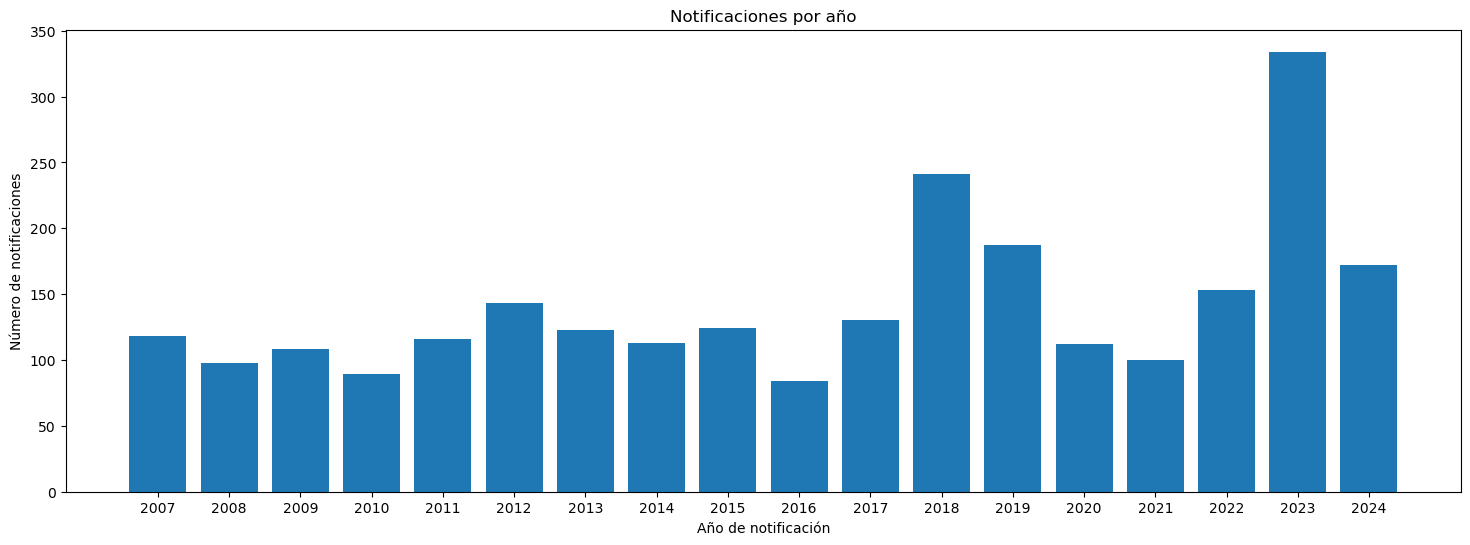

In [9]:
############################################################
### 🐧🐧**A.1.1 Tendencia general*¨*🐧🐧 ####
############################################################
#Se debe graficar el número total de notificaciones por año 
#se usa eno_com con desconocidos

plt.figure()

plt.figure(figsize=(18, 6))  # (ancho, alto)
plt.bar(
    notif_por_anho["anho_notificacion"],
    notif_por_anho["n_notificaciones"]
)

plt.xlabel("Año de notificación")
plt.xticks(
    ticks=notif_por_anho["anho_notificacion"],
    labels=notif_por_anho["anho_notificacion"].astype(int)
)
plt.ylabel("Número de notificaciones")
plt.title("Notificaciones por año")

plt.show()

El rango de datos se muestra entre 2007 y 2024, donde las notificaciones muestran variaciones moderadas.A partir de 2017 se observa un aumento que alcanza un máximo en 2023 reflejando un crecimiento reciente  
Aunque hay descensos intermedios la tendencia general es creciente en el largo plazo.

Estos cambios podrían asociarse tanto a  mejoras en el registro como a un incremento real de los eventos reportados, teniendo en cuenta que los años de pandemia entre 2021 y 2022.

Además, para obtener una vista un poco más interesante, a continuación se presenta el mismo gráfico separado por el top 5 de ENOS (dejando el resto de las variables en categorías de "otros") en donde se puede observar que el VIH, la Parotiditis y el Coqueluche predominan con el paso del tiempo hasta llegar al 2023, en donde la Sifilis hace más presencia hasta el 2024.

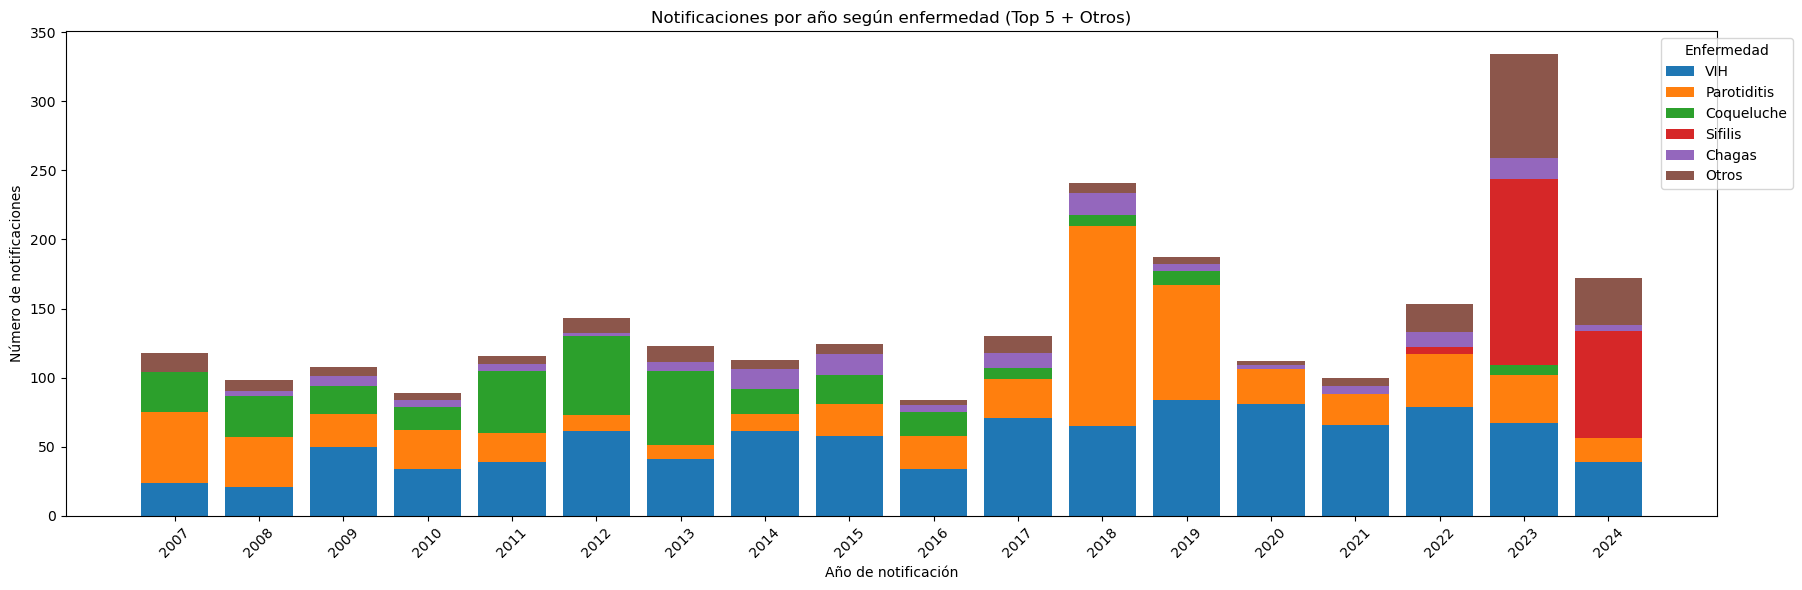

In [10]:
top_5_enos = eno_com["ENO"].value_counts().head(5).index

eno_com["ENO_top5"] = eno_com["ENO"].where(eno_com["ENO"].isin(top_5_enos), "Otros")

tabla_stack = (
    eno_com.groupby(["anho_notificacion", "ENO_top5"])
    .size()
    .unstack(fill_value=0)
    
)

orden_cols = [eno for eno in top_5_enos if eno in tabla_stack.columns]
if "Otros" in tabla_stack.columns:
    orden_cols = orden_cols + ["Otros"]

tabla_stack = tabla_stack[orden_cols]

plt.figure(figsize=(18, 6))

bottom = None

for eno in tabla_stack.columns:
    if bottom is None:
        plt.bar(tabla_stack.index, tabla_stack[eno], label=eno)
        bottom = tabla_stack[eno]
    else:
        plt.bar(tabla_stack.index, tabla_stack[eno], bottom=bottom, label=eno)
        bottom = bottom + tabla_stack[eno]

plt.xlabel("Año de notificación")
plt.ylabel("Número de notificaciones")
plt.title("Notificaciones por año según enfermedad (Top 5 + Otros)")
plt.xticks(tabla_stack.index, rotation=45)
plt.legend(title="Enfermedad", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


---

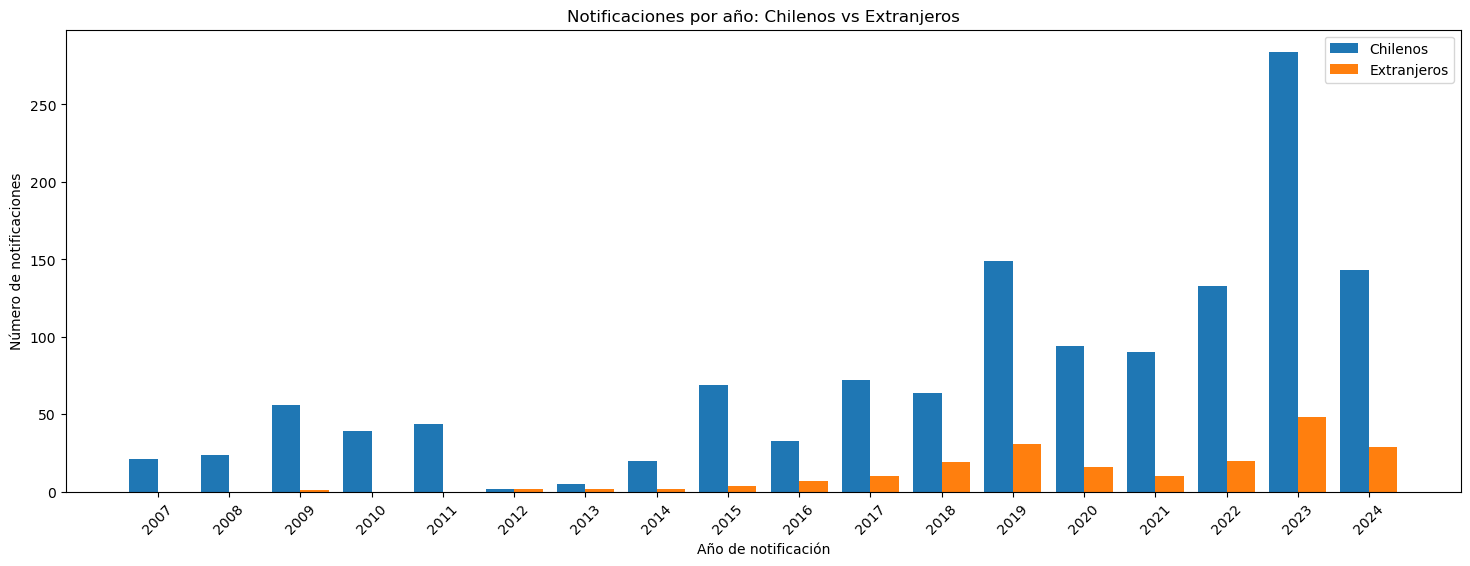

In [11]:

############################################################
### 🐧🐧**A.1.2 Tendencia por nacionalidad*¨*🐧🐧 ####
############################################################
#Se debe graficar el número total de notificaciones por año 
#se usa eno_com_ce SIN desconocidos


# Agrupar por año y nacionalidad
agrupado = (
    eno_com_ce.groupby(["anho_notificacion", "nacionalidad"])
    .size()
    .unstack(fill_value=0)
)


plt.figure(figsize=(18, 6))

x = agrupado.index

plt.bar(x - 0.2, agrupado["Chile"], width=0.4, label="Chilenos")
plt.bar(x + 0.2, agrupado["Extranjero"], width=0.4, label="Extranjeros")

plt.xlabel("Año de notificación")
plt.ylabel("Número de notificaciones")
plt.title("Notificaciones por año: Chilenos vs Extranjeros")

plt.legend()
plt.xticks(x, x.astype(int), rotation=45)

plt.show()

En el gráfico se observa un de notificaciones en población chilena a lo largo de todo el rango de años aunque con una tendencia a aumentar en personas extranjeras desde el año 2016 con leves bajas entre años, observando además el máximo de notificaciones en el año 2023 lo cual puede estar relacionado con el término de pandemia.

Con ello el aumento en ambos grupos en los últimos años sugiere una expansión general del fenómeno más que un cambio aislado en una sola población  

---
### **🐧🐧A.2 Perfiles de enfermedades (1.5 pts) 🐧🐧**


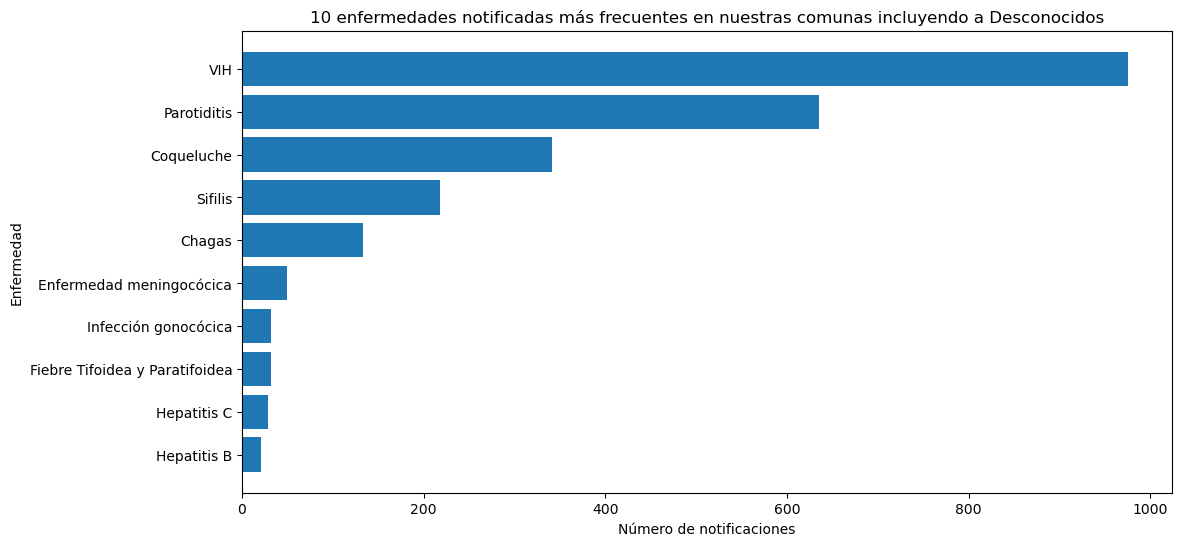

In [12]:
############################################################
### 🐧🐧**A.2.1 Principales enfermedades en general*¨*🐧🐧 ####
############################################################

#Muestra las 10 enfermedades notificadas más frecuentes...
# en tus comunas considerando todos los años. Preséntalo como un gráfico de barras horizontal.
##se usa eno_com CON desconocidos

top_10_eno = (
    eno_com["ENO"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(12, 6))
plt.barh(top_10_eno.index, top_10_eno.values)

plt.xlabel("Número de notificaciones")
plt.ylabel("Enfermedad")
plt.title("10 enfermedades notificadas más frecuentes en nuestras comunas incluyendo a Desconocidos")

plt.show()



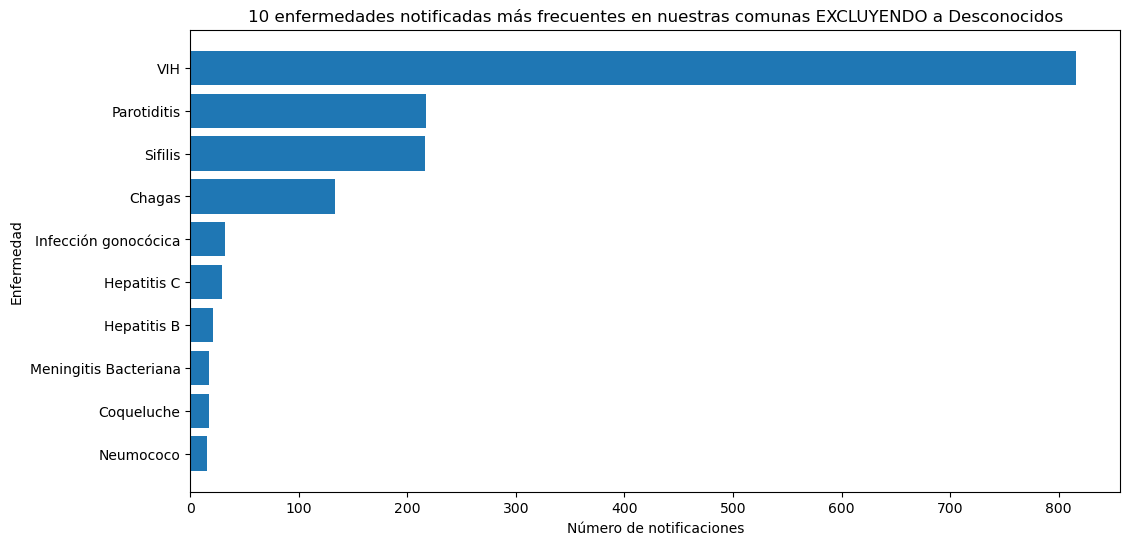

In [13]:
#se usa eno_com_ce SIN desconocidos

top_10_eno = (
    eno_com_ce["ENO"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(12, 6))
plt.barh(top_10_eno.index, top_10_eno.values)

plt.xlabel("Número de notificaciones")
plt.ylabel("Enfermedad")
plt.title("10 enfermedades notificadas más frecuentes en nuestras comunas EXCLUYENDO a Desconocidos")

plt.show()


---

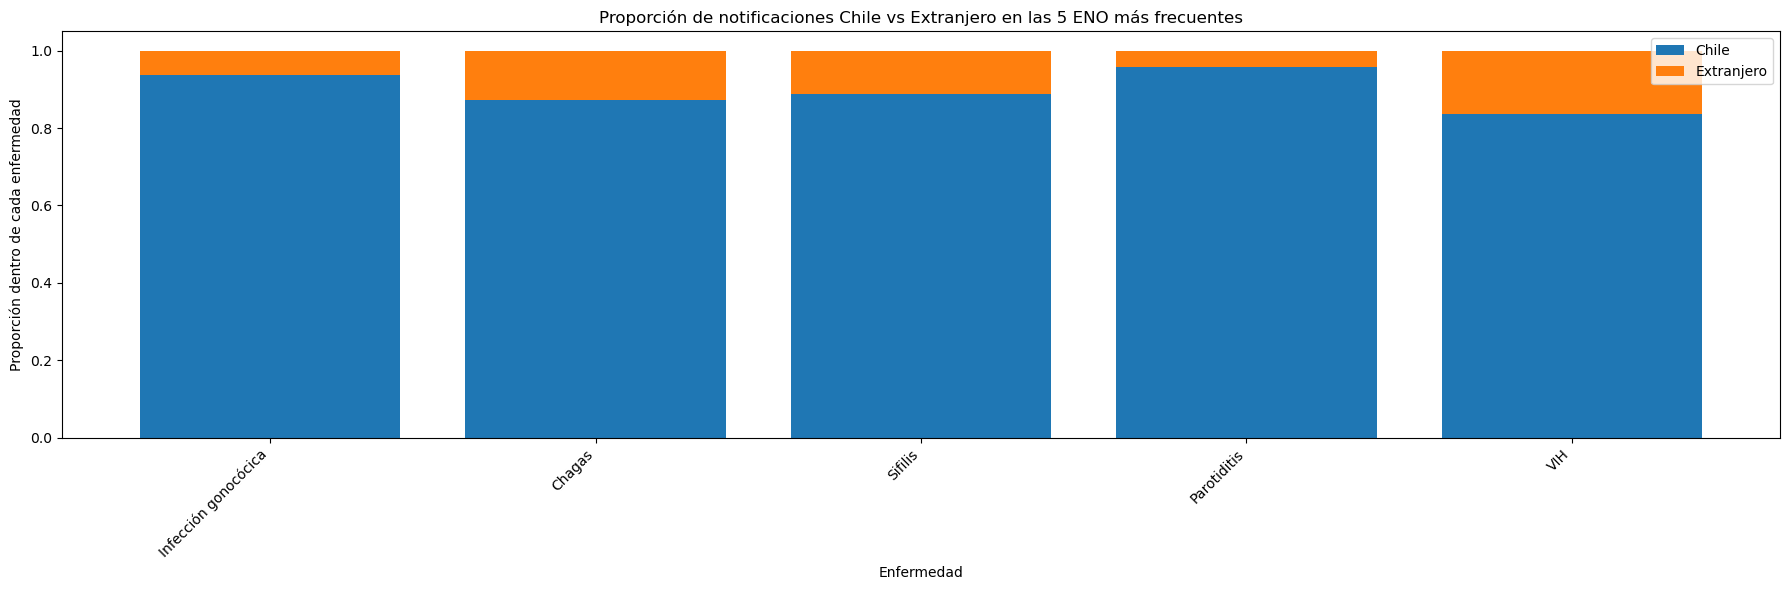

In [14]:

############################################################
### 🐧🐧**A.2.2 Perfiles de enfermedades por nacionalidad*¨*🐧🐧 ####
############################################################

#Para cada una de las 5 enfermedades más frecuentes, calcula la proporción de notificaciones chilenas vs. extranjeras...
# ...excluyendo "Desconocido"). Preséntalo como un gráfico de barras agrupadas o apiladas.

#se usa eno_com_ce SIN desconocidos


top_5_eno = (
    eno_com_ce["ENO"]
    .dropna()
    .value_counts()
    .head(5)
    .index
)

df_top5 = eno_com_ce[eno_com_ce["ENO"].isin(top_5_eno)]

tabla = (
    df_top5.groupby(["ENO", "nacionalidad"])
    .size()
    .unstack(fill_value=0)
)

prop_tabla = tabla.div(tabla.sum(axis=1), axis=0)
prop_tabla = prop_tabla.loc[tabla.sum(axis=1).sort_values().index]

plt.figure(figsize=(18, 6))

x = range(len(prop_tabla))

# Chile abajo
plt.bar(x, prop_tabla["Chile"], label="Chile")

# Extranjero arriba (apilado sobre Chile)
plt.bar(x, prop_tabla["Extranjero"], 
        bottom=prop_tabla["Chile"], 
        label="Extranjero")

plt.xticks(x, prop_tabla.index, rotation=45, ha="right")
plt.ylabel("Proporción dentro de cada enfermedad")
plt.xlabel("Enfermedad")
plt.title("Proporción de notificaciones Chile vs Extranjero en las 5 ENO más frecuentes")
plt.legend()
plt.tight_layout()
plt.show()


El gráfico anterior muestra que la proporción de notificaciones en chilenos es mayor que la de extranjeros, teniendo una  mayor proporción de Parotiditis. En extranjeros, estas proporciones varía entre enfermedades, siendo mayor en VIH y Chagas y menor en parotiditis e infección gonocócica. Sin embargo, para poder analizar de mejor manera sobre esto, necesitamos considerar la población de las comunas, de forma de normalizar estos datos.

Con ayuda de los resultados de la tarea 1, se generó un nuevo gráfico el cúal muestra los datos normalizados con una tasa de notificación por cada 100.000 habitantes, de forma de corregir las diferencias en el tamaño poblacional entre ambos grupos.Siguiendo la fórmula:

Tasa de notificación por 100.000 habitantes=
número de notificaciones\población del grupo* 100000

La lógica es primero dividir el número de notificaciones por la cantidad de habitantes del grupo correspondiente, para obtener la frecuencia relativa de casos, y luego multiplicar por 100.000 para expresar esa frecuencia en una escala más interpretable. De este modo, el resultado indica cuántas notificaciones habría por cada 100.000 habitantes.

In [15]:
#nos apoyamos de la tarea 1 para obtener la población total, chilena y extranjera por comuna
t1 = pd.read_csv("output_tarea1_comuna_summary.csv")
t1.head()



,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13107,Huechuraba,101808,92790,8381,8.28,36.0,35.0,12.77,14.12,63.92,75.80,0.44
1,13112,La Pintana,175421,166483,7732,4.44,34.0,32.0,10.01,11.47,55.71,67.68,0.49
2,13502,Alhué,7768,6871,879,11.34,37.0,28.0,10.60,11.38,63.78,77.52,0.51
3,13504,María Pinto,15352,14996,319,2.08,38.0,31.0,10.60,11.46,61.08,69.20,0.52
4,13602,El Monte,37497,36404,915,2.45,36.0,34.0,10.90,12.53,60.75,69.14,0.50


In [16]:
#obtenemos el total de población chilena y extranjera sumando las comunas de nuestro análisis
pop_df = t1.copy()
pop_df[["nombre_comuna", "pop_total", "pop_chilean", "pop_foreign", "pct_foreign"]]

total_pop_chilean = pop_df["pop_chilean"].sum()
total_pop_foreign = pop_df["pop_foreign"].sum()

print(f"Población chilena total: {total_pop_chilean}")
print(f"Población extranjera total: {total_pop_foreign}")

Población chilena total: 317544
Población extranjera total: 18226


In [17]:
tabla_rates = tabla.copy()

#calculamos la tasa por cada 100.000 habitantes para chilenos y extranjeros
tabla_rates["tasa_chile_100k"] = tabla_rates.get("Chile") / total_pop_chilean * 100000
tabla_rates["tasa_extranjero_100k"] = tabla_rates.get("Extranjero") / total_pop_foreign * 100000

tabla_rates = tabla_rates[["tasa_chile_100k", "tasa_extranjero_100k"]]
tabla_rates = tabla_rates.sort_values("tasa_chile_100k")

tabla_rates

nacionalidad,tasa_chile_100k,tasa_extranjero_100k
ENO,,
Infección gonocócica,9.447510,10.973335
Chagas,36.530371,93.273346
Sifilis,60.464062,131.680018
Parotiditis,65.502733,49.380007
VIH,215.088303,729.726764


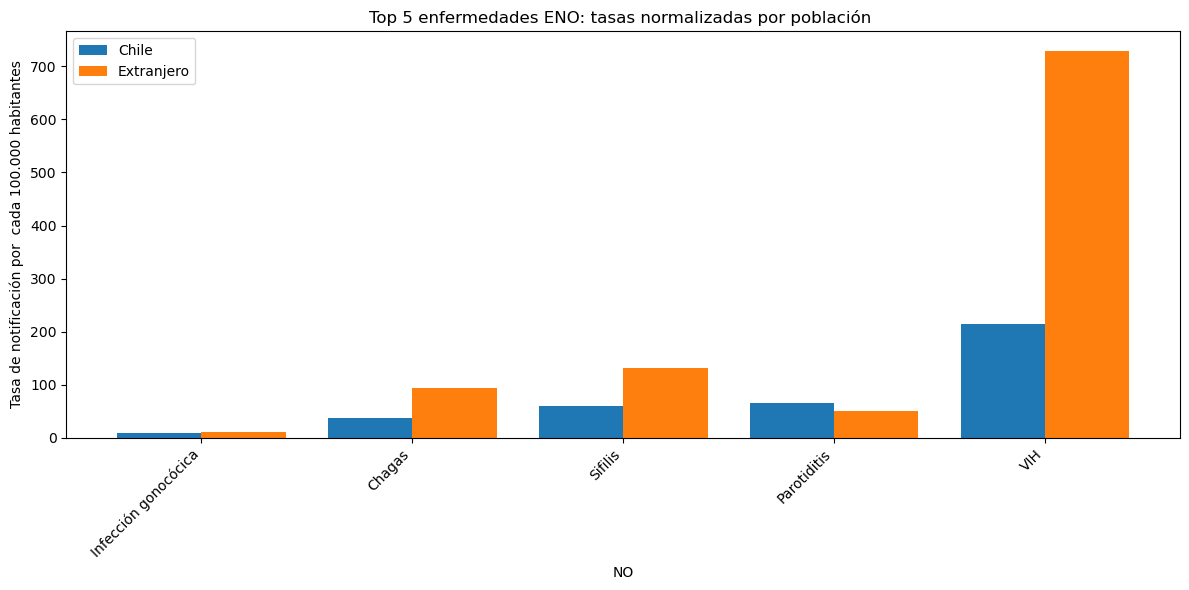

In [18]:
plt.figure(figsize=(12, 6))

x = range(len(tabla_rates))

plt.bar([i - 0.2 for i in x], tabla_rates["tasa_chile_100k"], width=0.4, label="Chile")
plt.bar([i + 0.2 for i in x], tabla_rates["tasa_extranjero_100k"], width=0.4, label="Extranjero")

plt.xticks(x, tabla_rates.index, rotation=45, ha="right")
plt.ylabel("Tasa de notificación por  cada 100.000 habitantes")
plt.xlabel("NO")
plt.title("Top 5 enfermedades ENO: tasas normalizadas por población ")
plt.legend()
plt.tight_layout()
plt.show()

Al normalizar, se observan diferencias importantes en la carga relativa de algunas enfermedades. En el caso del VIH, este presenta la mayor brecha entre ambos grupos, con una tasa más alta en población extranjera que en población chilena, caso que ocurre al igual que con las ENO: Chagas y Sífilis.

En cambio, Parotiditis muestra una tasa algo mayor en población chilena, y la Infección gonocócica presenta tasas bajas bastante cercanas entre ambos grupos. 

Finalmente, estos nuevos resultados sugieren que, al ajustar por tamaño poblacional, ciertas enfermedades están sobrerrepresentadas descriptivamente en la población extranjera de las comunas analizadas.

Sin embargo, como punto a tener en cuenta, estas tasas deben interpretarse con cuidado, ya que corresponden a una medida descriptiva cruda: el numerador agrega notificaciones de varios años, mientras que el denominador poblacional proviene del resumen demográfico de la Tarea 1.

---

In [19]:
############################################################
### 🐧🐧**A.2.3 Distribución por grupo etario para la enfermedad principal*¨*🐧🐧 ####
############################################################

#Escoge la enfermedad más común en tus comunas. 
#Grafica su distribución por grupo etario (grupo_edad), separada por nacionalidad. Comenta cualquier diferencia visible en el perfil etario.

#se usa eno_com_ce SIN desconocidos

#nos quedamos con el top 1 de ENO
top_1_ENO = eno_com_ce["ENO"].value_counts().idxmax()
print(f"La enfermedad más frecuente es: {top_1_ENO}")


La enfermedad más frecuente es: VIH


In [20]:
#filtramos la data solo para la enfermedad más frecuente, el VIH
df_top_1_ENO  = eno_com_ce[eno_com_ce ["ENO"] == top_1_ENO].copy()
print(f"Número de registros para {top_1_ENO}: {len(df_top_1_ENO)}")

Número de registros para VIH: 816


In [21]:
#vemos la distribución por grupo de edad de la tabla filtrada por VIH
df_top_1_ENO["grupo_edad"].value_counts()

grupo_edad
25-29    175
30-34    142
20-24    131
35-39    100
40-44     72
45-49     53
50-54     51
15-19     34
55-59     21
60-64     14
65-69      8
75-79      5
70-74      3
***        3
00-04      2
05-09      2
Name: count, dtype: int64

In [22]:
#se identificaron registros con grupo de edad "***", que no aportan información útil, por lo que se eliminan
df_top_1_ENO = df_top_1_ENO[df_top_1_ENO["grupo_edad"] != "***"]

In [23]:
tabla_edad = (
    df_top_1_ENO.groupby(["grupo_edad", "nacionalidad"])
    .size()
    .unstack(fill_value=0)
)

orden_edades = [
    "00-04", "05-09", "15-19", "20-24", "25-29",
    "30-34", "35-39", "40-44", "45-49",
    "50-54", "55-59", "60-64", "65-69",
    "70-74", "75-79"
]

tabla_edad = tabla_edad.reindex(orden_edades)
tabla_edad

nacionalidad,Chile,Extranjero
grupo_edad,,
00-04,1,1
05-09,2,0
15-19,32,2
20-24,114,17
25-29,141,34
30-34,113,29
35-39,80,20
40-44,54,18
45-49,45,8


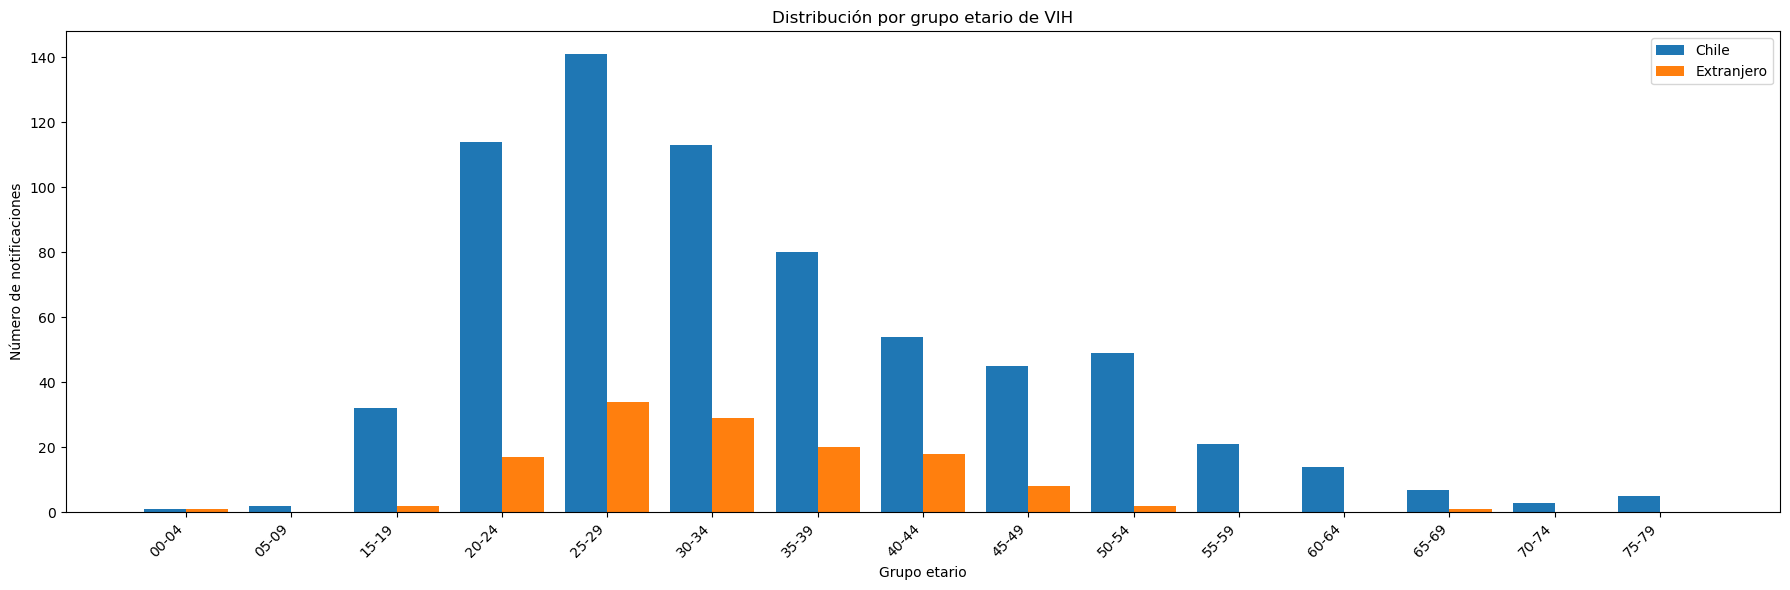

In [24]:
plt.figure(figsize=(18, 6))

x = range(len(tabla_edad))

plt.bar([i - 0.2 for i in x], tabla_edad.get("Chile", 0), width=0.4, label="Chile")
plt.bar([i + 0.2 for i in x], tabla_edad.get("Extranjero", 0), width=0.4, label="Extranjero")

plt.xticks(x, tabla_edad.index, rotation=45, ha="right")
plt.ylabel("Número de notificaciones")
plt.xlabel("Grupo etario")
plt.title(f"Distribución por grupo etario de {top_1_ENO}")
plt.legend()
plt.tight_layout()
plt.show()

En el gráfico anterior se observa la distribución por grupo etario del VIH, la enfermedad ENO más frecuente en las comunas analizadas. Se aprecia un patrón similar entre chilenos y extranjeros: las notificaciones aumentan hasta alcanzar su máximo en el grupo de 25 a 29 años y luego disminuyen progresivamente a medida que aumenta la edad.

---

### **🐧🐧A.3 Visión espacial (0.5 pts) 🐧🐧**

In [25]:
###############################################
### 🐧🐧 **A.3.1 Conteo de notificaciones por comuna** 🐧🐧 ####
###############################################

# Mapeo de códigos a nombres de comuna
comunas_dict = {
    "13107": "Huechuraba",
    "13112": "La Pintana",
    "13502": "Alhué",
    "13504": "María Pinto",
    "13602": "El Monte"
}

# 1) Conteo total de notificaciones ENO por comuna
eno_por_comuna = (
    eno_com.groupby("codigo_comuna_residencia")
    .size()
    .reset_index(name="eno_total")
)

eno_por_comuna["nombre_comuna"] = eno_por_comuna["codigo_comuna_residencia"].map(comunas_dict)

eno_por_comuna = eno_por_comuna[["codigo_comuna_residencia", "nombre_comuna", "eno_total"]]
eno_por_comuna = eno_por_comuna.sort_values("eno_total", ascending=False)

eno_por_comuna

,codigo_comuna_residencia,nombre_comuna,eno_total
1,13112,La Pintana,1507
0,13107,Huechuraba,832
4,13602,El Monte,146
3,13504,María Pinto,32
2,13502,Alhué,28


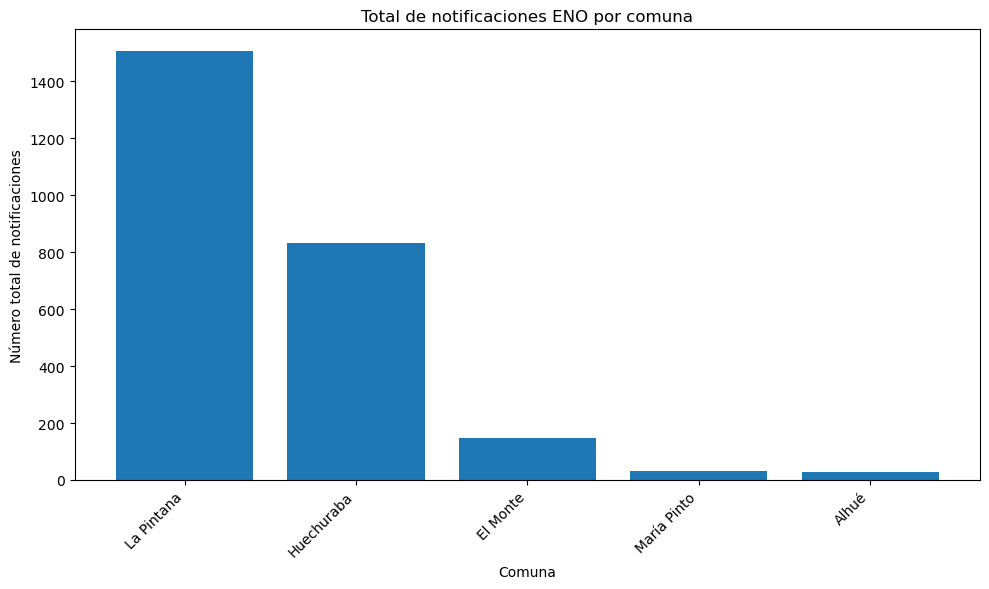

In [26]:
plt.figure(figsize=(10, 6))
plt.bar(eno_por_comuna["nombre_comuna"], eno_por_comuna["eno_total"])

plt.xlabel("Comuna")
plt.ylabel("Número total de notificaciones")
plt.title("Total de notificaciones ENO por comuna")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Podemos notar que en La Pintana existe un mayor número de notificaciones seguido de Huechuraba, esto tiene sentido producto de la cantidad de personas existentes en cada una de las comunas. Por lo que realizaremos una normalización.

In [27]:
#se obtiene la población total por comuna desde la tarea 1, para demostrar lo anterior
t1_motrar= t1[["nombre_comuna", "pop_total"]]
t1_motrar

,nombre_comuna,pop_total
0,Huechuraba,101808
1,La Pintana,175421
2,Alhué,7768
3,María Pinto,15352
4,El Monte,37497


---

Con ello, a continuación realizaremos la normalización mencionada

In [28]:
#  Unir con población total desde la tabla de Tarea 1
eno_comuna_rate = eno_por_comuna.merge(
    t1[["nombre_comuna", "pop_total"]],
    on="nombre_comuna",
    how="left"
)

# Calcular tasa cruda por 10.000 habitantes
eno_comuna_rate["eno_rate_per_10k"] = (
    eno_comuna_rate["eno_total"] / eno_comuna_rate["pop_total"] * 10000
)

eno_comuna_rate = eno_comuna_rate.sort_values("eno_rate_per_10k", ascending=False)

eno_comuna_rate

,codigo_comuna_residencia,nombre_comuna,eno_total,pop_total,eno_rate_per_10k
0,13112,La Pintana,1507,175421,85.907617
1,13107,Huechuraba,832,101808,81.722458
2,13602,El Monte,146,37497,38.936448
4,13502,Alhué,28,7768,36.045314
3,13504,María Pinto,32,15352,20.844190


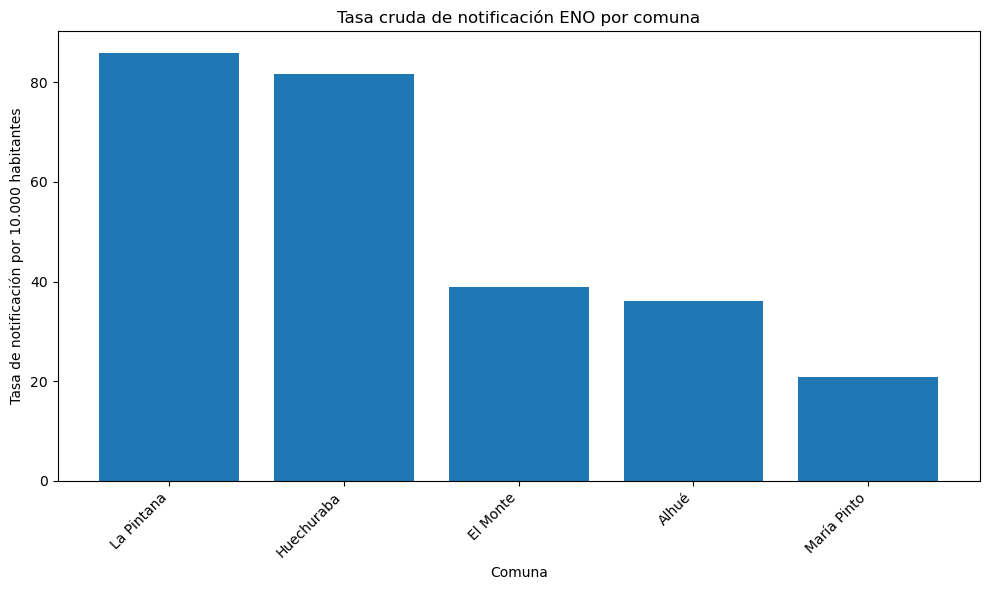

In [29]:
plt.figure(figsize=(10, 6))
plt.bar(eno_comuna_rate["nombre_comuna"], eno_comuna_rate["eno_rate_per_10k"])

plt.xlabel("Comuna")
plt.ylabel("Tasa de notificación por 10.000 habitantes")
plt.title("Tasa cruda de notificación ENO por comuna")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Lo anterior solo fue para comprobar el gráfico anterior, de modo de observar cómo se comportan los datos normalizados. Continuamos utilizando la tabla sin normalizar.

In [30]:

# Top 5 enfermedades ENO globales en mis comunas
top_5_enos = eno_com["ENO"].value_counts().head(5).index

# Crear categoría Top 5 + Otros
eno_com["ENO_top5"] = eno_com["ENO"].where(eno_com["ENO"].isin(top_5_enos), "Otros")

# Agrupar por comuna y tipo de ENO
eno_comuna_tipo = (
    eno_com.groupby(["codigo_comuna_residencia", "ENO_top5"])
    .size()
    .unstack(fill_value=0)
)

# Ordenar columnas: top 5 primero, Otros al final
orden_cols = [eno for eno in top_5_enos if eno in eno_comuna_tipo.columns]
if "Otros" in eno_comuna_tipo.columns:
    orden_cols = orden_cols + ["Otros"]

eno_comuna_tipo = eno_comuna_tipo[orden_cols]

# Agregar nombre de comuna
eno_comuna_tipo["nombre_comuna"] = eno_comuna_tipo.index.map(comunas_dict)

# Reordenar comunas por total de notificaciones
eno_comuna_tipo["total"] = eno_comuna_tipo[orden_cols].sum(axis=1)
eno_comuna_tipo = eno_comuna_tipo.sort_values("total", ascending=False)

eno_comuna_tipo

ENO_top5,VIH,Parotiditis,Coqueluche,Sifilis,Chagas,Otros,nombre_comuna,total
codigo_comuna_residencia,,,,,,,,
13112,583,335,259,121,77,132,La Pintana,1507
13107,291,270,73,74,33,91,Huechuraba,832
13602,82,17,7,14,10,16,El Monte,146
13504,12,7,0,4,5,4,María Pinto,32
13502,7,6,2,5,8,0,Alhué,28


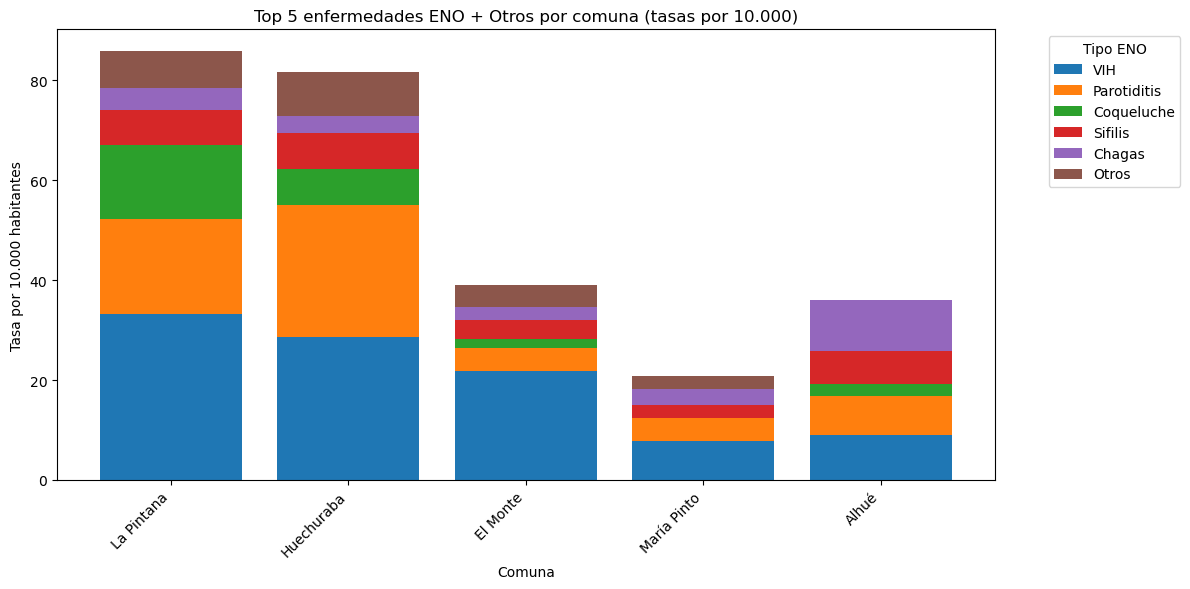

In [31]:
# Copia para no pisar la original
tasas_comuna_tipo = eno_comuna_tipo.copy()

# Hacer merge sobre la copia, no sobre eno_comuna_tipo
tasas_comuna_tipo = tasas_comuna_tipo.merge(
    t1[["nombre_comuna", "pop_total"]],
    on="nombre_comuna",
    how="left"
)

# Ordenar por tasa total si quieres
tasas_comuna_tipo["tasa_total"] = tasas_comuna_tipo[orden_cols].sum(axis=1)
tasas_comuna_tipo = tasas_comuna_tipo.sort_values("tasa_total", ascending=False)

# Calcular tasas por 10.000 para cada categoría ENO
for col in orden_cols:
    tasas_comuna_tipo[col] = tasas_comuna_tipo[col] / tasas_comuna_tipo["pop_total"] * 10000

# Gráfico de barras apiladas
plt.figure(figsize=(12, 6))

bottom = [0] * len(tasas_comuna_tipo)

for col in orden_cols:
    plt.bar(
        tasas_comuna_tipo["nombre_comuna"],
        tasas_comuna_tipo[col],
        bottom=bottom,
        label=col
    )
    bottom = bottom + tasas_comuna_tipo[col].values

plt.xticks(rotation=45, ha="right")
plt.ylabel("Tasa por 10.000 habitantes")
plt.xlabel("Comuna")
plt.title("Top 5 enfermedades ENO + Otros por comuna (tasas por 10.000)")
plt.legend(title="Tipo ENO", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [32]:
tasas_comuna_tipo

,VIH,Parotiditis,Coqueluche,Sifilis,Chagas,Otros,nombre_comuna,total,pop_total,tasa_total
0,33.234333,19.096915,14.764481,6.897692,4.389440,7.524755,La Pintana,1507,175421,1507
1,28.583215,26.520509,7.170360,7.268584,3.241396,8.938394,Huechuraba,832,101808,832
2,21.868416,4.533696,1.866816,3.733632,2.666880,4.267008,El Monte,146,37497,146
3,7.816571,4.559666,0.000000,2.605524,3.256905,2.605524,María Pinto,32,15352,32
4,9.011329,7.723996,2.574665,6.436663,10.298661,0.000000,Alhué,28,7768,28


En esta sección se calcularon los conteos totales de notificaciones ENO por comuna, agregando todos los años disponibles. Luego, utilizando la población total obtenida en la Tarea 1 (`pop_total`), se construyó una tasa cruda de notificación por 10.000 habitantes para comparar de forma más justa comunas con tamaños poblacionales distintos.

Es importante señalar que estos conteos comunales corresponden a una subestimación de la carga real de notificaciones, debido a que una fracción importante del dataset ENO presenta la comuna de residencia anonimizada como `"*****"`, por lo que esos registros no pueden ser asignados territorialmente.

---



In [33]:
###########################################################
### 🐧🐧 A.4 Tabla resumen ENO a nivel comuna 🐧🐧 ####
###########################################################

eno_summary = eno_comuna_rate.copy()

# renombrar código
eno_summary = eno_summary.rename(columns={
    "codigo_comuna_residencia": "codigo_comuna"
})

# Conteos por nacionalidad
chile_counts = (
    eno_com[eno_com["nacionalidad"] == "Chile"]
    .groupby("codigo_comuna_residencia")
    .size()
)

foreign_counts = (
    eno_com[eno_com["nacionalidad"] == "Extranjero"]
    .groupby("codigo_comuna_residencia")
    .size()
)

desconocido_counts = (
    eno_com[eno_com["nacionalidad"] == "Desconocido"]
    .groupby("codigo_comuna_residencia")
    .size()
)

eno_summary["eno_chilean"] = (
    eno_summary["codigo_comuna"]
    .map(chile_counts)
    .fillna(0)
    .astype(int)
)

eno_summary["eno_foreign"] = (
    eno_summary["codigo_comuna"]
    .map(foreign_counts)
    .fillna(0)
    .astype(int)
)

eno_summary["eno_desconocido"] = (
    eno_summary["codigo_comuna"]
    .map(desconocido_counts)
    .fillna(0)
    .astype(int)
)

# Top 3 enfermedades por comuna
top3 = (
    eno_com.groupby("codigo_comuna_residencia")["ENO"]
    .apply(lambda x: ", ".join(x.value_counts().head(3).index))
)

eno_summary["eno_top3_diseases"] = eno_summary["codigo_comuna"].map(top3)

# columnas finales
eno_summary = eno_summary[
    [
        "codigo_comuna",
        "nombre_comuna",
        "eno_total",
        "eno_chilean",
        "eno_foreign",
        "eno_desconocido",
        "eno_top3_diseases",
        "eno_rate_per_10k"
    ]
]

eno_summary

,codigo_comuna,nombre_comuna,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k
0,13112,La Pintana,1507,755,102,650,"VIH, Parotiditis, Coqueluche",85.907617
1,13107,Huechuraba,832,456,68,308,"VIH, Parotiditis, Sifilis",81.722458
2,13602,El Monte,146,93,18,35,"VIH, Parotiditis, Sifilis",38.936448
4,13502,Alhué,28,14,9,5,"Chagas, VIH, Parotiditis",36.045314
3,13504,María Pinto,32,24,4,4,"VIH, Parotiditis, Chagas",20.844190


In [34]:
eno_summary.to_csv("tarea2_eno_summary.csv", index=False)

---



---

### **Parte B: GRD – Egresos Hospitalarios (5 pts)**
### **🐧🐧B.0 Carga y limpieza de datos (1.5 pts) 🐧🐧**

Ahora, en esta nueva parte de la tarea, se cargarán los archivos GRD de los años 2022, 2023 y 2024 (correspondientes a egresos hospitalarios). Cada archivo de estos años se encuentra como un .zip, los datos se encuentran  delimitados por `|` y están codificados tanto en Latin-1, como en utf-16.

Por otro lado, para este trabajo solo se seleccionarán las columnas necesarias para el desarrollo de la parte B de la tarea.

In [35]:
#cargar librerias
import zipfile
import matplotlib.ticker as mticker
import geopandas as gpd

In [36]:
# Primero que todo comprobamos el encoding de cada año
# para el año 2022 y 2023 son UTF-16, mientras que 2024 es Latin-1

for year in [2022, 2023, 2024]:
    zippath = f"GRD_PUBLICO_{year}.zip"

    with zipfile.ZipFile(zippath) as z:
        txt = z.namelist()[0]

        with z.open(txt) as f:
            raw = f.read(100)

    print(f"{year}")
    print(raw[:40])

2022
b'\xff\xfeC\x00O\x00D\x00_\x00H\x00O\x00S\x00P\x00I\x00T\x00A\x00L\x00|\x00C\x00I\x00P\x00_\x00E\x00N\x00'
2023
b'\xff\xfeC\x00O\x00D\x00_\x00H\x00O\x00S\x00P\x00I\x00T\x00A\x00L\x00|\x00C\x00I\x00P\x00_\x00E\x00N\x00'
2024
b'COD_HOSPITAL|ID_BENEFICIARIO|SEXO|FECHA_'


In [37]:

##################################################################
### 🐧🐧**B.0.1 Cargar los datos de GRD de 2022, 2023, 2024*¨*🐧🐧 ####
##################################################################

# Cargamos columnas recomendados por la tarea
grd_cols = [
    "COMUNA", "NACIONALIDAD", "SEXO", "FECHA_NACIMIENTO",
    "FECHA_INGRESO", "FECHAALTA", "TIPOALTA",
    "DIAGNOSTICO1", "DIAGNOSTICO2",
    "IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD",
    "IR_29301_COD_GRD", "TIPO_INGRESO",
    "ESPECIALIDAD_MEDICA"
]

# Con lo anterior, 2022 y 2023 son UTF-16, mientras que 2024 es Latin-1
encoding_por_año = {
    2022: "utf-16",
    2023: "utf-16",
    2024: "latin-1"
}

frames = []
for year in [2022, 2023, 2024]:
    zippath = f"GRD_PUBLICO_{year}.zip"
    encoding = encoding_por_año[year]

    with zipfile.ZipFile(zippath) as z:
        txtname = z.namelist()[0]
        print(f"Leyendo {year} ({txtname}) con encoding={encoding}...") #agregando cargas 

        with z.open(txtname) as f:
            df_year = pd.read_csv(
                f, sep="|", usecols=grd_cols,
                encoding=encoding, low_memory=False
            )
            df_year["year"] = year
            frames.append(df_year)
            print(f"{len(df_year):,} filas del año {year}")
            print("")

grd = pd.concat(frames, ignore_index=True)
print(f"\nTotal discharges: {len(grd):,}")
print(grd.shape)

Leyendo 2022 (GRD_PUBLICO_2022.txt) con encoding=utf-16...
932,840 filas del año 2022

Leyendo 2023 (GRD_PUBLICO_2023.txt) con encoding=utf-16...
1,039,587 filas del año 2023

Leyendo 2024 (GRD_PUBLICO_2024.txt) con encoding=latin-1...
1,085,813 filas del año 2024


Total discharges: 3,058,240
(3058240, 15)


---

Entonces con lo anterior sabemos que tenemos en total casi 3 millones de filas en grd, por lo que sigamos avanzando. Antes de filtrar por nuestras comunas, debemos investigar el nombre de estas en el dataset grd, de forma de verificar el nombre correcto.

In [38]:
sorted(grd["COMUNA"].dropna().unique())

['AISÉN',
 'ALGARROBO',
 'ALHUÉ',
 'ALTO BIOBÍO',
 'ALTO DEL CARMEN',
 'ALTO HOSPICIO',
 'ANCUD',
 'ANDACOLLO',
 'ANGOL',
 'ANTOFAGASTA',
 'ANTUCO',
 'ANTÁRTICA',
 'ARAUCO',
 'ARICA',
 'BUIN',
 'BULNES',
 'CABILDO',
 'CABO DE HORNOS',
 'CABRERO',
 'CALAMA',
 'CALBUCO',
 'CALDERA',
 'CALERA',
 'CALERA DE TANGO',
 'CALLE LARGA',
 'CAMARONES',
 'CAMIÑA',
 'CANELA',
 'CARAHUE',
 'CARTAGENA',
 'CASABLANCA',
 'CASTRO',
 'CATEMU',
 'CAUQUENES',
 'CAÑETE',
 'CERRILLOS',
 'CERRO NAVIA',
 'CHAITÉN',
 'CHANCO',
 'CHAÑARAL',
 'CHEPICA',
 'CHIGUAYANTE',
 'CHILE CHICO',
 'CHILLAN',
 'CHILLAN VIEJO',
 'CHIMBARONGO',
 'CHOLCHOL',
 'CHONCHI',
 'CISNES',
 'COBQUECURA',
 'COCHAMÓ',
 'COCHRANE',
 'CODEGUA',
 'COELEMU',
 'COIHAIQUE',
 'COIHUECO',
 'COINCO',
 'COLBÚN',
 'COLCHANE',
 'COLINA',
 'COLLIPULLI',
 'COLTAUCO',
 'COMBARBALÁ',
 'CON CON',
 'CONCEPCIÓN',
 'CONCHALÍ',
 'CONSTITUCIÓN',
 'CONTULMO',
 'COPIAPO',
 'COQUIMBO',
 'CORONEL',
 'CORRAL',
 'CUNCO',
 'CURACAUTÍN',
 'CURACAVÍ',
 'CURACO DE VÉLEZ',

In [39]:
##################################################################
### 🐧🐧**B.0.2 Filtrar por nuestras columnas*¨*🐧🐧 ####
##################################################################


# Con lo anterior, ya tenemos los nombres, con lo cual:
my_comuna_names = ["HUECHURABA", "LA PINTANA", "ALHUÉ", "MARIA PINTO", "EL MONTE"]

# Filtrar el GRD por nuestras comunas
grd_com = grd[grd["COMUNA"].isin(my_comuna_names)].copy()
print(f"\nDischarges en mis comunas: {len(grd_com):,}")

# Discharges por año
print("\nDischarges (Egresos hospitalarios) por año:")
print(grd_com["year"].value_counts().sort_index())


Discharges en mis comunas: 57,827

Discharges (Egresos hospitalarios) por año:
year
2022    18309
2023    19404
2024    20114
Name: count, dtype: int64


Con lo anterior ya obtenemos los egresos hospitalarios por año, aquí, se pueden observar una tendencia al alza con el pasar de los años.

---


La base GRD no incluye una variable explícita de duración de estadía. Por ello, esta deberá calcularse utilizando la diferencia entre la fecha de alta y la fecha de ingreso hospitalario.

La nueva variable, se deberá describir su distribución mediante medidas resumen: promedio,mediana, mínimo, máximo.


>(los registros con la variable negativa indican errores de datos, las filas correspondientes deben eliminarse y reportarse al ser eliminadas)


In [40]:
# Antes, vemos si usamos el dayfirst=true (dd/mm/yyyy) en vez de (mm/dd/yyyy)
grd_com["FECHA_INGRESO"].dropna().astype(str).head(20)


18      2022-09-24
91      2022-09-27
94      2022-02-11
114     2022-07-30
271     2022-03-25
273     2022-10-17
320     2022-04-20
322     2022-05-13
471     2022-06-04
476     2022-11-10
534     2022-02-03
745     2022-10-04
886     2022-12-24
935     2022-03-08
953     2022-11-24
990     2022-02-04
1014    2022-01-18
1097    2022-02-26
1101    2022-05-01
1194    2022-07-06
Name: FECHA_INGRESO, dtype: str

Ok, usemos  format="%Y-%m-%d

In [41]:
##################################################################
### 🐧🐧**B.0.3 Calcular duración de estadía hospitalaria*¨*🐧🐧 ####
##################################################################


# Convertir las fechas a datetime
grd_com["fecha_ingreso_dt"] = pd.to_datetime(grd_com["FECHA_INGRESO"],  format="%Y-%m-%d", errors="coerce")
grd_com["fecha_alta_dt"]    = pd.to_datetime(grd_com["FECHAALTA"],     format="%Y-%m-%d", errors="coerce")

# Calcular largo del estadía en días con lo anterior
grd_com["los"] = (grd_com["fecha_alta_dt"] - grd_com["fecha_ingreso_dt"]).dt.days


# Filas negativas son errores, las eliminamos y reportamos, el ==0 es válido (salen el mismo día)
n_negativos = (grd_com["los"] < 0).sum()

if n_negativos == 0:
    print(f"Filas con LOS < 0 (errores): {n_negativos}")
    print("WOA NO HAY NEGATIVOS?!?!?")
    print("")
else:
    print(f"Filas con LOS < 0 (errores): {n_negativos}")
    print(":( LOS NEGATIVOS FUERON ELIMINADOS")

grd_com = grd_com[grd_com["los"] >= 0].copy()

# LOS == 0 es válido (alta el mismo día)
print(grd_com["los"].describe().round(2))

Filas con LOS < 0 (errores): 0
WOA NO HAY NEGATIVOS?!?!?

count    38423.00
mean         5.53
std         12.66
min          0.00
25%          0.00
50%          2.00
75%          5.00
max        503.00
Name: los, dtype: float64


De lo anterior, no se identificaron registros con estadía negativa. Además, la duración de hospitalización presenta una mediana de 2 días y un promedio de entre 5 a 6 días, aunque con algunos casos extremos de larga permanencia como lo es un caso de 503 días. 

---
La variable NACIONALIDAD contiene el nombre completo del país de origen de cada persona (por ejemplo: `CHILE`, `PERU`, `VENEZUELA (REPUBLICA BOLIVARIANA DE)`).

A partir de esta variable, se constriuye una clasificación binaria llamada `nat_group`, que agrupe los registros en dos categorías:

- **Chilean**: personas cuya nacionalidad es Chilena.  (dice CHILE)
- **Foreign**: personas con cualquier otra nacionalidad distinta de Chile. (no dice CHILE)

Finalmente, se debe reportar la distribución de frecuencias de esta nueva variable.

In [42]:
##################################################################
### 🐧🐧**B.0.4 Crear agrupación de nacionalidad*¨*🐧🐧 ####
##################################################################

grd_com["nat_group"] = grd_com["NACIONALIDAD"].apply(
    lambda x: "Chilean" if str(x).strip().upper() == "CHILE" else "Foreign"
)

# Con lo anterior se cre+o una nueva columna "nat_group" con valores "Chilean" o "Foreign" según corresponda.   
print(grd_com["nat_group"].value_counts())
print("")
print(grd_com["nat_group"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

nat_group
Chilean    36959
Foreign     1464
Name: count, dtype: int64

nat_group
Chilean    96.19%
Foreign     3.81%
Name: proportion, dtype: str


---

La variable `DIAGNOSTICO1` contiene el código del diagnóstico principal registrado en cada egreso hospitalario. Para facilitar su interpretación, estos códigos deben vincularse con la tabla de referencia CIE-10 (Clasificación Internacional de Enfermedades). Con lo anterior se agregará información adicional al dataset, incluyendo:

- **Descripción**: nombre legible del diagnóstico.  
- **Capítulo**: grupo o categoría diagnóstica dentro de la clasificación CIE-10. Es como el que engloba un grupo de descripciones)


Por ejemplo:
- Capítulo:Enfermedades del sistema circulatorio
- Código: I10
- Descripción: Hipertensión esencial

> Una vez realizado el cruce, se debe reportar cuántos registros no lograron encontrar coincidencia en la tabla de referencia, es decir, aquellos casos donde la variable `Capitulo` quede vacía o nula tras la unión.

In [43]:
#librería para xlsx en caso de no tenerla instalada
#!pip install openpyxl

In [44]:
##################################################################
### 🐧🐧**B.0.5 Vincular diagnósticos con CIE-10*¨*🐧🐧 ####
##################################################################

# Cargar  CIE-10
cie10 = pd.read_excel("CIE-10.xlsx", sheet_name="CIE 10")

# Nuevamente hay que ver el nombre de las columnas
print("Columnas en CIE-10:", cie10.columns.tolist())

# Join: DIAGNOSTICO1 del GRD a Codigo del CIE-10
# Evitamos filas duplicadas en el CIE-10 usando drop_duplicates() para quedarnos solo con un registro por código, y así evitar que el merge genere filas adicionales
grd_com = grd_com.merge(
    cie10[["Código", "Descripción", "Capítulo"]].drop_duplicates("Código"),
    left_on="DIAGNOSTICO1",
    right_on="Código",
    how="left"
)

# Reportar filas que no hicieron match (Capítulo es null)
n_sin_match = grd_com["Capítulo"].isna().sum()
pct_sin_match = n_sin_match / len(grd_com) * 100
print(f"\nFilas sin match en CIE-10: {n_sin_match:,} ({pct_sin_match:.2f}%)")

Columnas en CIE-10: ['Versión', 'Código', 'Descripción', 'Categoría', 'Sección', 'Capítulo']

Filas sin match en CIE-10: 4 (0.01%)


Con lo anterior podemos ver que nuestro grd_com ahora tiene las nuevas 2 columnas

In [45]:
grd_com.head(10)

,SEXO,FECHA_NACIMIENTO,COMUNA,NACIONALIDAD,TIPO_INGRESO,ESPECIALIDAD_MEDICA,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,...,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,year,fecha_ingreso_dt,fecha_alta_dt,los,nat_group,Código,Descripción,Capítulo
0,MUJER,1953-05-27,LA PINTANA,CHILE,URGENCIA,MEDICINA INTERNA,2022-09-24,2022-09-26,DOMICILIO,J21.8,...,3,3,2022,2022-09-24,2022-09-26,2.0,Chilean,J21.8,Bronquiolitis aguda debida a otros microorgani...,Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...
1,MUJER,1975-11-09,LA PINTANA,CHILE,URGENCIA,UROLOGÍA,2022-09-27,2022-09-28,DOMICILIO,N13.6,...,2,1,2022,2022-09-27,2022-09-28,1.0,Chilean,N13.6,Pionefrosis,Cap.14 ENFERMEDADES DEL APARATO GENITOURINARI...
2,MUJER,2000-06-10,LA PINTANA,CHILE,OBSTETRICA,OBSTETRICIA Y GINECOLOGÍA,2022-02-11,2022-02-11,DOMICILIO,O99.8,...,2,1,2022,2022-02-11,2022-02-11,0.0,Chilean,O99.8,Otras enfermedades especificadas y afecciones ...,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)"
3,MUJER,1970-04-06,LA PINTANA,CHILE,PROGRAMADA,OBSTETRICIA Y GINECOLOGÍA,2022-07-30,2022-08-03,DOMICILIO,D25.0,...,1,1,2022,2022-07-30,2022-08-03,4.0,Chilean,D25.0,Leiomioma submucoso del útero,Cap.02 NEOPLASIAS (C00-D49)
4,MUJER,1993-05-16,EL MONTE,CHILE,OBSTETRICA,OBSTETRICIA Y GINECOLOGÍA,2022-03-25,2022-03-28,DOMICILIO,O13,...,1,1,2022,2022-03-25,2022-03-28,3.0,Chilean,O13,Hipertensión gestacional [inducida por el emba...,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)"
5,MUJER,1944-08-31,LA PINTANA,CHILE,URGENCIA,CIRUGÍA GENERAL,2022-10-17,2022-10-21,DOMICILIO,I77.1,...,2,1,2022,2022-10-17,2022-10-21,4.0,Chilean,I77.1,Estrechez arterial,Cap.09 ENFERMEDADES DEL APARATO CIRCULATORIO ...
6,MUJER,1963-05-17,LA PINTANA,CHILE,URGENCIA,MEDICINA INTERNA,2022-04-20,2022-05-03,DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS,D17.5,...,2,1,2022,2022-04-20,2022-05-03,13.0,Chilean,D17.5,Tumor benigno lipomatoso de los órganos intraa...,Cap.02 NEOPLASIAS (C00-D49)
7,MUJER,2000-01-20,EL MONTE,CHILE,OBSTETRICA,OBSTETRICIA Y GINECOLOGÍA,2022-05-13,2022-05-17,DOMICILIO,O62.0,...,1,1,2022,2022-05-13,2022-05-17,4.0,Chilean,O62.0,Contracciones primarias inadecuadas,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)"
8,MUJER,1947-10-04,LA PINTANA,CHILE,PROGRAMADA,OFTALMOLOGÍA,2022-06-04,2022-06-04,DOMICILIO,S02.30,...,0,0,2022,2022-06-04,2022-06-04,0.0,Chilean,S02.30,"Fractura del suelo de la órbita, cerrada","Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ..."
9,MUJER,1997-07-21,LA PINTANA,CHILE,OBSTETRICA,OBSTETRICIA Y GINECOLOGÍA,2022-11-10,2022-11-12,DOMICILIO,O62.1,...,1,1,2022,2022-11-10,2022-11-12,2.0,Chilean,O62.1,Inercia uterina secundaria,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)"


--

### **🐧🐧B.1 Perfil diagnóstico (1.5 pts) 🐧🐧**


En esta parte se deben agrupar los egresos hospitalarios según el **capítulo CIE-10** (`Capitulo`) y mostrar los **10 capítulos más frecuentes** mediante un gráfico de barras horizontal.

Debemos identificar qué categorias concentran la mayor parte de las hospitalizaciones en nuestras comunas. Además, debemos incluir un breve comentario interpretando cuáles son las categorías diagnósticas predominantes.



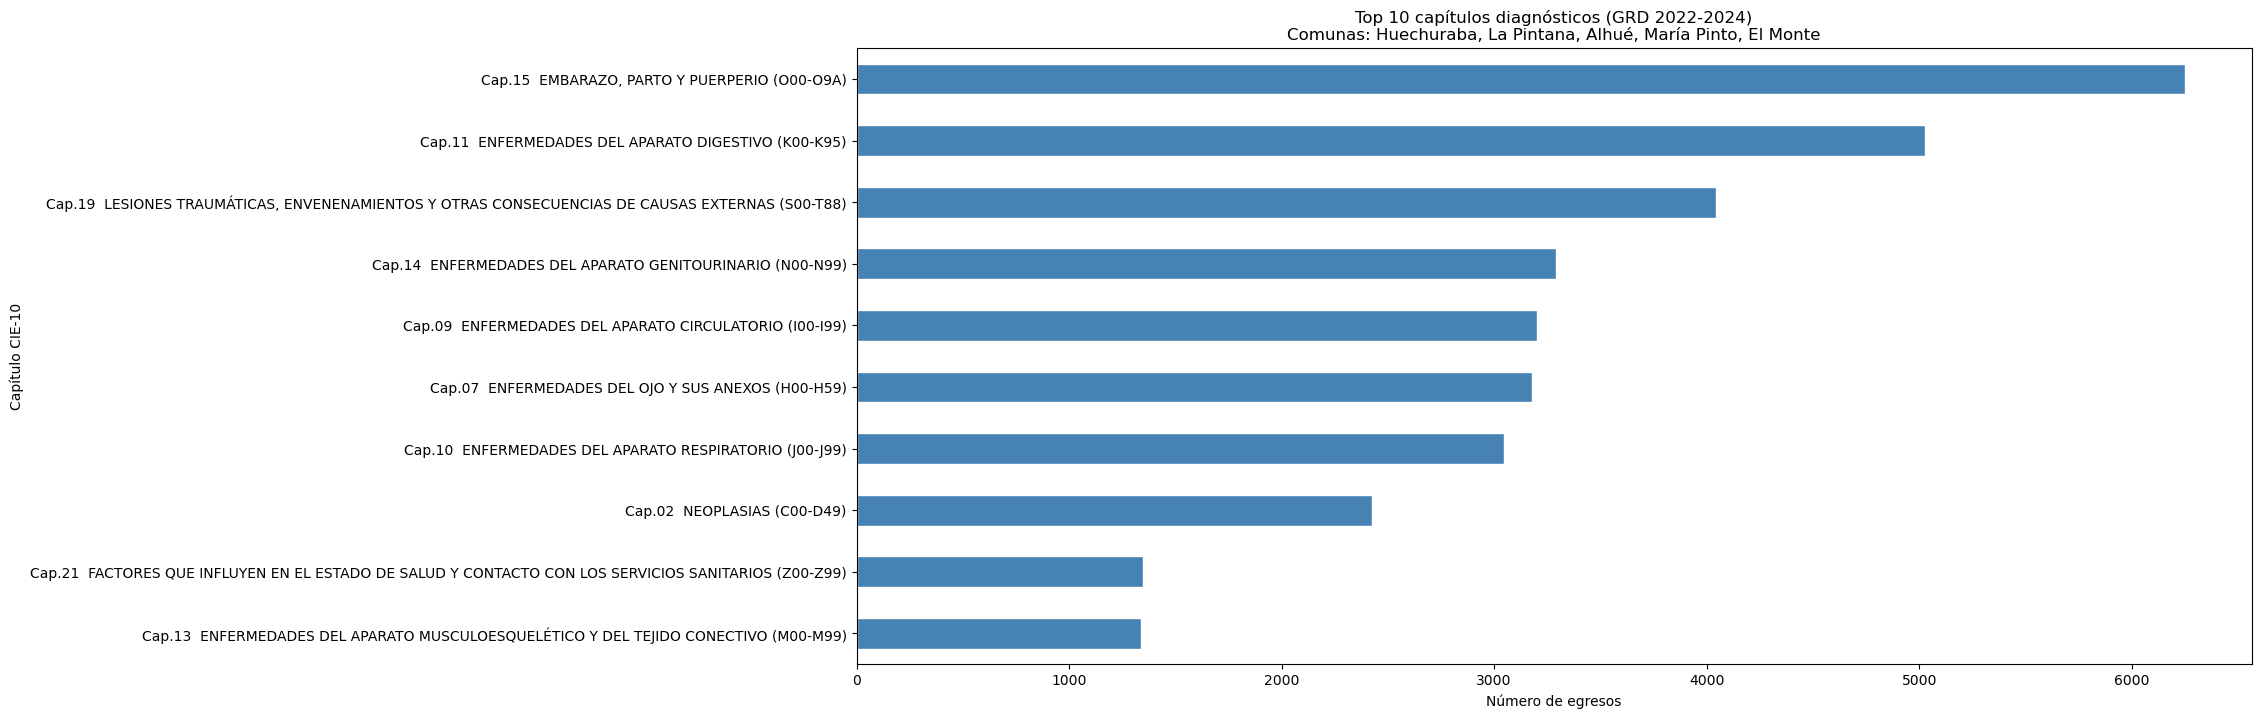

In [46]:
##################################################################
### 🐧🐧**B.1.1 Principales capítulos diagnósticos*¨*🐧🐧 ####
##################################################################

# Contar egresos por capítulo CIE-10
top_capitulos = (
    grd_com["Capítulo"]
    .value_counts()
    .head(10) #top 10
    .sort_values()  # orden ascendente para que el mayor quede arriba en el gráfico
)

fig, ax = plt.subplots(figsize=(18, 8))
top_capitulos.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")

ax.set_title("Top 10 capítulos diagnósticos (GRD 2022-2024)\nComunas: Huechuraba, La Pintana, Alhué, María Pinto, El Monte", fontsize=12)
ax.set_xlabel("Número de egresos")
ax.set_ylabel("Capítulo CIE-10")
plt.show()


In [47]:
# Tabla de conteos por capítulo
print("\nTop 10 capítulos (tabla):")
print(top_capitulos.sort_values(ascending=False).to_frame("egresos"))


Top 10 capítulos (tabla):
                                                    egresos
Capítulo                                                   
Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A)          6251
Cap.11  ENFERMEDADES DEL APARATO DIGESTIVO (K00...     5025
Cap.19  LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y...     4044
Cap.14  ENFERMEDADES DEL APARATO GENITOURINARIO...     3291
Cap.09  ENFERMEDADES DEL APARATO CIRCULATORIO (...     3201
Cap.07  ENFERMEDADES DEL OJO Y SUS ANEXOS (H00-...     3176
Cap.10  ENFERMEDADES DEL APARATO RESPIRATORIO (...     3047
Cap.02  NEOPLASIAS (C00-D49)                           2426
Cap.21  FACTORES QUE INFLUYEN EN EL ESTADO DE S...     1347
Cap.13  ENFERMEDADES DEL APARATO MUSCULOESQUELÉ...     1339


Las hospitalizaciones en las comunas seleccionadas se concentran en **Capítulo 15: Embarazo, parto y puerperio**, que aparece como la categoría más frecuente entre los años 2022 y 2024. A lo que le siguen los egresos asociados a **enfermedades del aparato digestivo**, seguidos por **lesiones traumáticas, envenenamientos y otras consecuencias de causas externas**. 

Esto indica que la carga hospitalaria es repartida entre egresos obstétricos, patologías digestivas, lesiones y enfermedades crónicas o de atención especializada. Sin embargo, existe un predominio del capítulo de embarazo, parto y puerperio, lo que sugiere que la atención materno-obstétrica constituye uno de los componentes más relevantes del perfil hospitalario local.

---

Ahora debemos identificar los 15 diagnósticos específicos más frecuentes, utilizando esta vez la variable `Descripcion`, y presentarlos en un gráfico de barras horizontal.

A diferencia del análisis anterior, aquí ya no se trabaja con grandes grupos diagnósticos, sino con los diagnósticos concretos.


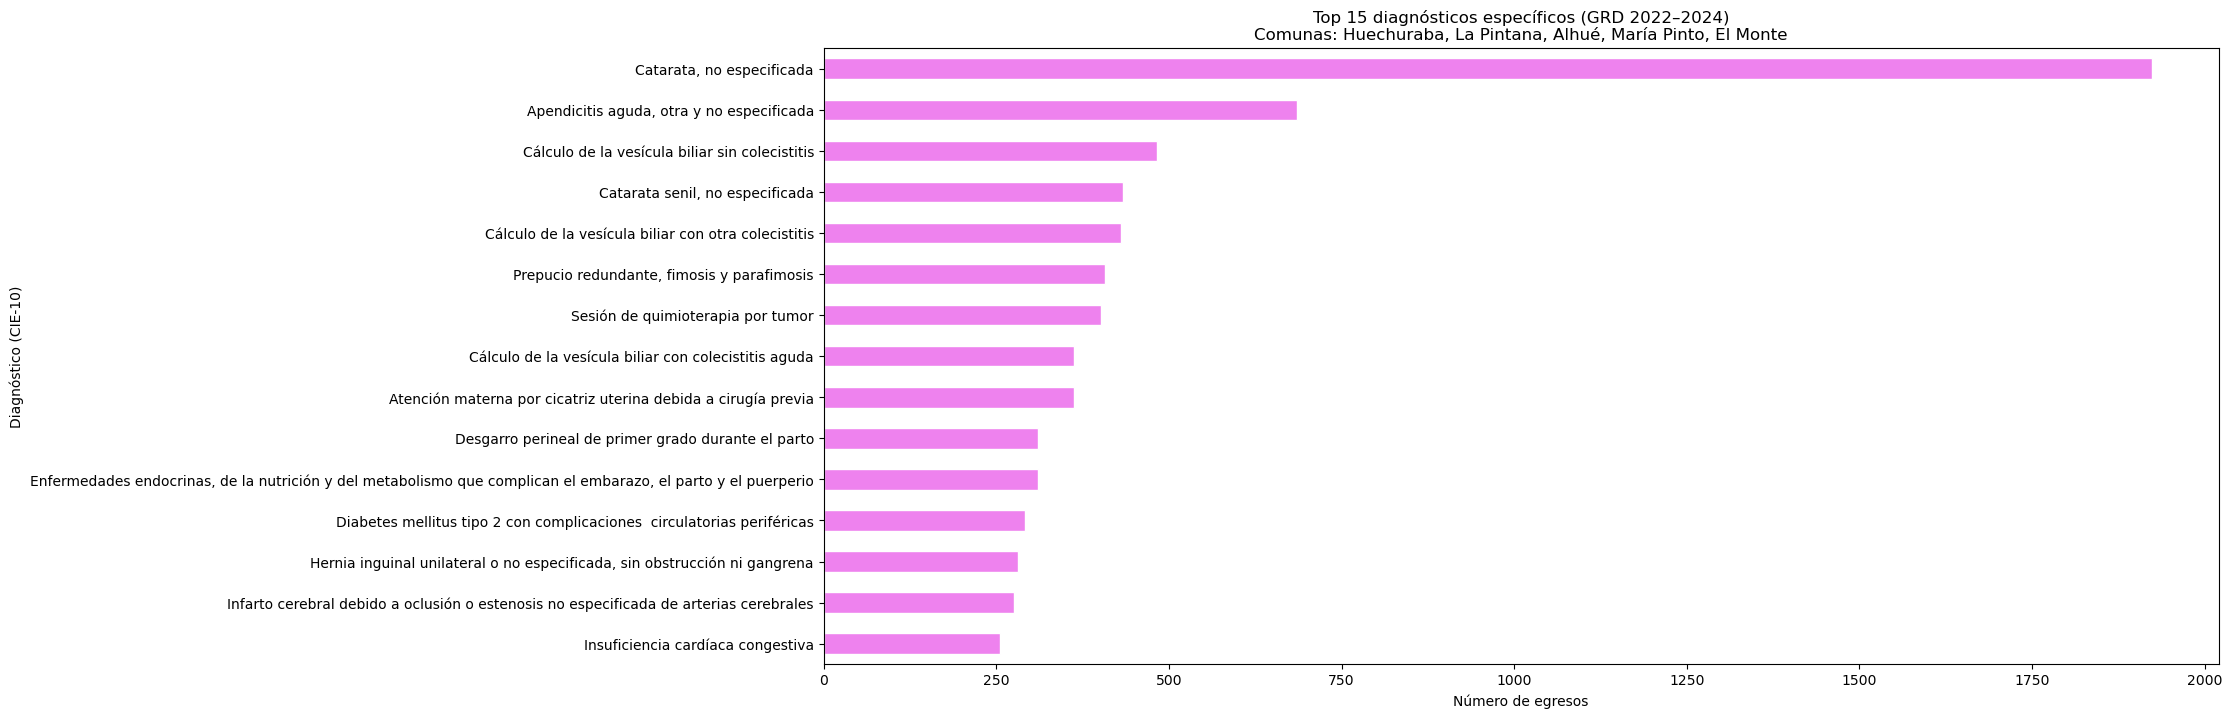

In [48]:
##################################################################
### 🐧🐧**B.1.2 Principales diagnósticos específicos*¨*🐧🐧 ####
##################################################################

#usamos Descripción en  vez de capítulo
top_diag = (
    grd_com["Descripción"]
    .value_counts()
    .head(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(18, 8))
top_diag.plot(kind="barh", ax=ax, color="violet", edgecolor="white")

ax.set_title("Top 15 diagnósticos específicos (GRD 2022–2024)\nComunas: Huechuraba, La Pintana, Alhué, María Pinto, El Monte", fontsize=12)
ax.set_xlabel("Número de egresos")
ax.set_ylabel("Diagnóstico (CIE-10)")


plt.show()


In [49]:
# Tabla de conteos por descripción
print("\nTop 10 capítulos (tabla):")
print(top_diag.sort_values(ascending=False).to_frame("egresos"))


Top 10 capítulos (tabla):
                                                    egresos
Descripción                                                
Catarata, no especificada                              1924
Apendicitis aguda, otra y no especificada               685
Cálculo de la vesícula biliar sin colecistitis          483
Catarata senil, no especificada                         434
Cálculo de la vesícula biliar con otra colecist...      430
Prepucio redundante, fimosis y parafimosis              408
Sesión de quimioterapia por tumor                       402
Atención materna por cicatriz uterina debida a ...      362
Cálculo de la vesícula biliar con colecistitis ...      362
Desgarro perineal de primer grado durante el parto      311
Enfermedades endocrinas, de la nutrición y del ...      310
Diabetes mellitus tipo 2 con complicaciones  ci...      292
Hernia inguinal unilateral o no especificada, s...      281
Infarto cerebral debido a oclusión o estenosis ...      276
Insuficiencia

El diagnóstico más frecuente es **catarata no especificada** con más del doble de egresos que el siguiente diagnóstico. Este es seguido por apendicitis aguda y distintos trastornos de la vesícula biliar.

---
En esta parte se debe comparar la composición de los **5 capítulos diagnósticos más frecuentes** según nacionalidad, distinguiendo entre población **chilena** y **extranjera**.

Para ello, se debe calcular la proporción de egresos de cada grupo dentro de esos capítulos y representar el resultado en un gráfico de barras agrupadas o apiladas.

El objetivo es evaluar si existen capítulos diagnósticos donde la población extranjera tenga una participación relativamente alta. Para interpretar este resultado, se debe contextualizar con el `pct_foreign` calculado en la Tarea 1. Por ejemplo, si la población extranjera representa un 10% de la población total, pero concentra un 20% de los egresos en un determinado capítulo, ello constituye un hallazgo relevante.

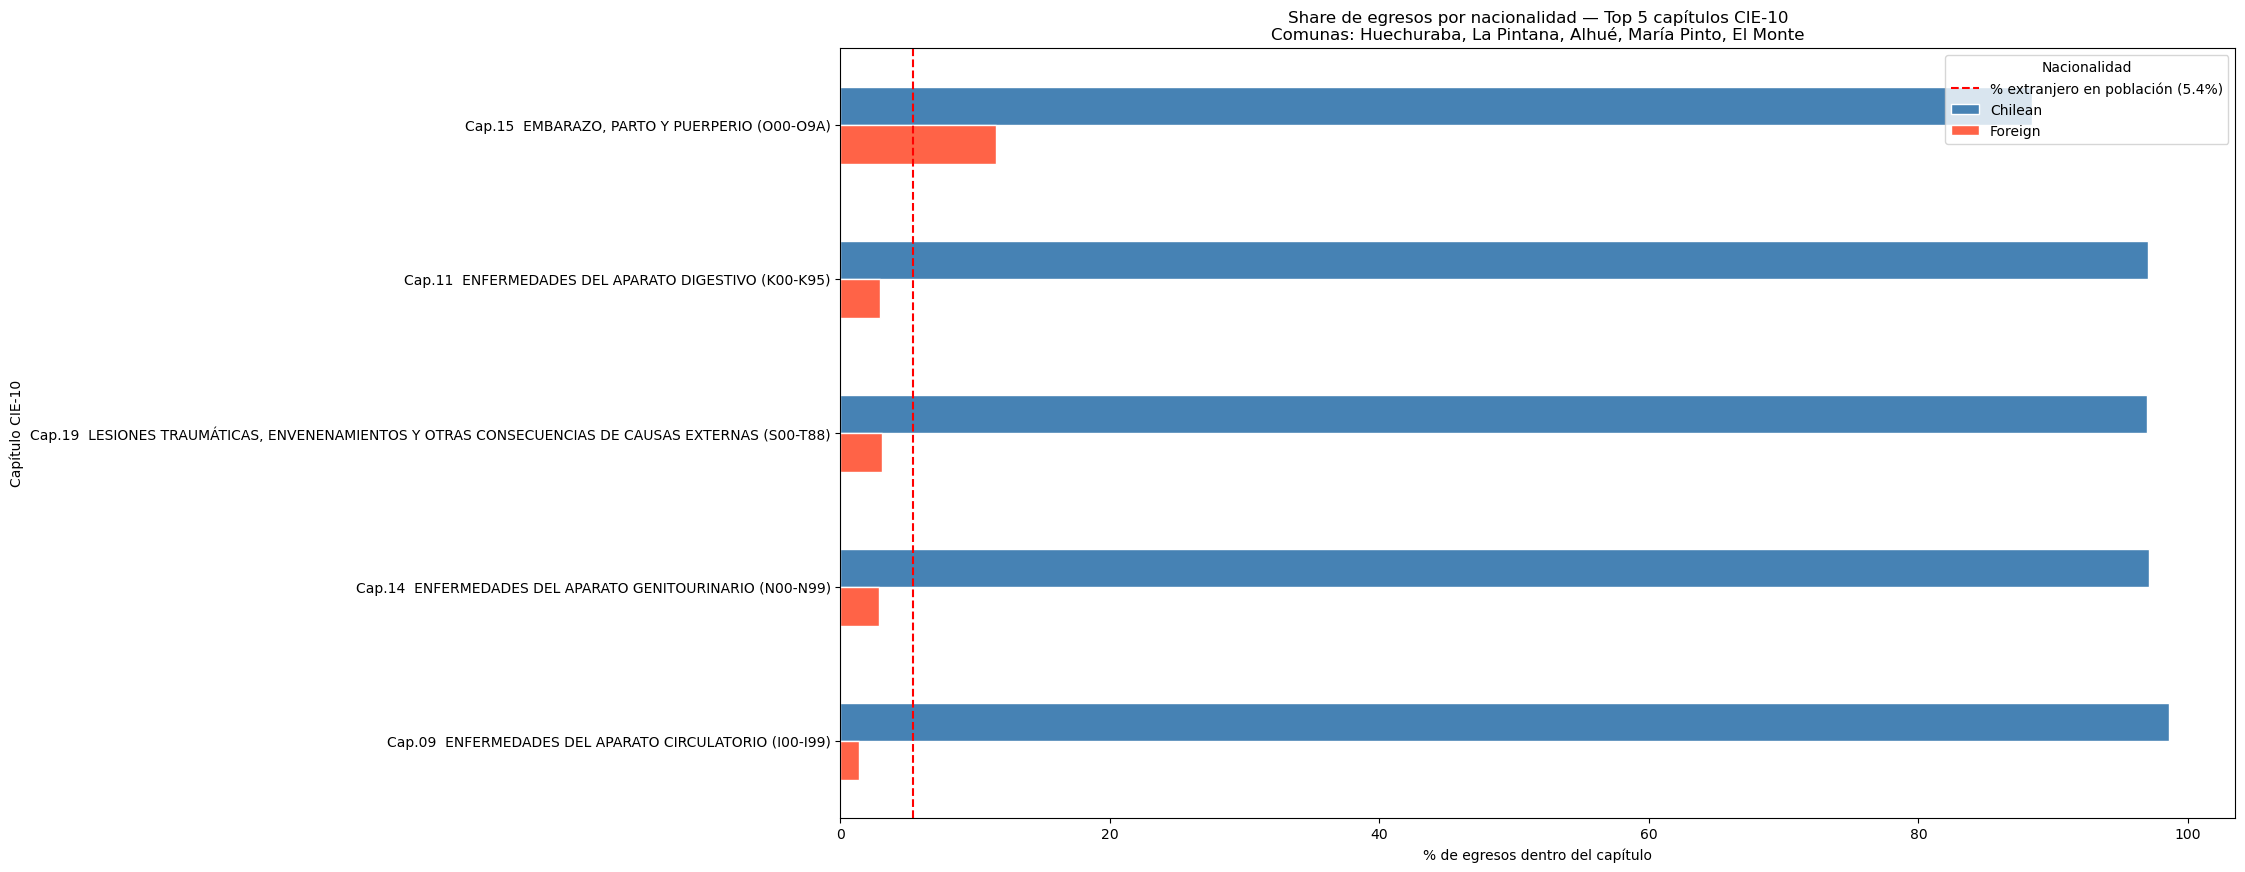

In [50]:
##################################################################
### 🐧🐧**B.1.3 Capítulos diagnósticos por nacionalidad, TOP 5*¨*🐧🐧 ####
##################################################################
# Identificar los top 5 capítulos
top5_caps = grd_com["Capítulo"].value_counts().head(5).index.tolist()

# Filtrar y contar por capítulo + nacionalidad
cap_nat = (
    grd_com[grd_com["Capítulo"].isin(top5_caps)]
    .groupby(["Capítulo", "nat_group"])
    .size()
    .reset_index(name="egresos")
)

# Calcular share dentro de cada capítulo
cap_nat["share"] = (
    cap_nat.groupby("Capítulo")["egresos"]
    .transform(lambda x: x / x.sum() * 100)
)

# Pivot para graficar
cap_pivot = (
    cap_nat.pivot(index="Capítulo", columns="nat_group", values="share")
    .fillna(0)
)

# Reordenar según el top 5 real
cap_pivot = cap_pivot.reindex(top5_caps)

fig, ax = plt.subplots(figsize=(18, 10))
cap_pivot.plot(kind="barh", ax=ax, color=["steelblue", "tomato"], edgecolor="white")

# Invertir eje y para que el top 1 quede arriba
ax.invert_yaxis()

# Línea de referencia
t1 = pd.read_csv("output_tarea1_comuna_summary.csv")
MY_COMUNAS = [13107, 13112, 13502, 13504, 13602]
my_t1 = t1[t1["codigo_comuna"].isin(MY_COMUNAS)]
pct_foreign_poblacion = my_t1["pop_foreign"].sum() / my_t1["pop_total"].sum() * 100

ax.axvline(
    pct_foreign_poblacion,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"% extranjero en población ({pct_foreign_poblacion:.1f}%)"
)

ax.set_title("Share de egresos por nacionalidad — Top 5 capítulos CIE-10\nComunas: Huechuraba, La Pintana, Alhué, María Pinto, El Monte", fontsize=12)
ax.set_xlabel("% de egresos dentro del capítulo")
ax.set_ylabel("Capítulo CIE-10")
ax.legend(title="Nacionalidad")

plt.show()


In [51]:

print(f"\nReferencia: extranjeros son el {pct_foreign_poblacion:.2f}% de la población total en tus comunas")
print("\nShare de egresos por capítulo y nacionalidad (%):")
print(cap_pivot.round(2))


Referencia: extranjeros son el 5.39% de la población total en tus comunas

Share de egresos por capítulo y nacionalidad (%):
nat_group                                           Chilean  Foreign
Capítulo                                                            
Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A)         88.42    11.58
Cap.11  ENFERMEDADES DEL APARATO DIGESTIVO (K00...    97.07     2.93
Cap.19  LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y...    96.93     3.07
Cap.14  ENFERMEDADES DEL APARATO GENITOURINARIO...    97.11     2.89
Cap.09  ENFERMEDADES DEL APARATO CIRCULATORIO (...    98.59     1.41


Como podemos notar en el gráfico, en los egresos según capítulos predominan los egresos de pacientes chilenos.

Sin embargo existe algo destacable en el capítulo de **embarazo, parto y puerperio**, donde los pacientes extranjeros alcanzan un **11,58%** de los egresos, cifra que es superior a su peso poblacional de referencia **5,39%**. Esto sugiere una mayor presencia relativa en este tipo de hospitalizaciones por parte de pacientes extranjeros.

---

### **🐧🐧B.2 Duración de estadía y severidad (1 pt) 🐧🐧**

En esta sección se debe comparar la **duración de estadía hospitalaria** (`los`) entre los apcientes **chileno** y **extranjero**.

Para ello, se deben calcular al menos dos medidas resumen para cada grupo:

- **promedio**
- **mediana**

Estos resultados deben presentarse en una tabla pequeña.

Además, se debe visualizar la distribución de `los`, limitando el análisis a estadías de hasta 30 días para facilitar la lectura del gráfico. Esta comparación puede realizarse mediante histogramas superpuestos o boxplots, diferenciando por nacionalidad.

Finalmente, se debe comentar si existen diferencias relevantes entre ambos grupos.

Largo de estadía, en días, por nacionalidad:
           mean  median  min    max      n
nat_group                                 
Chilean    5.58     2.0  0.0  503.0  36959
Foreign    4.05     2.0  0.0   83.0   1464


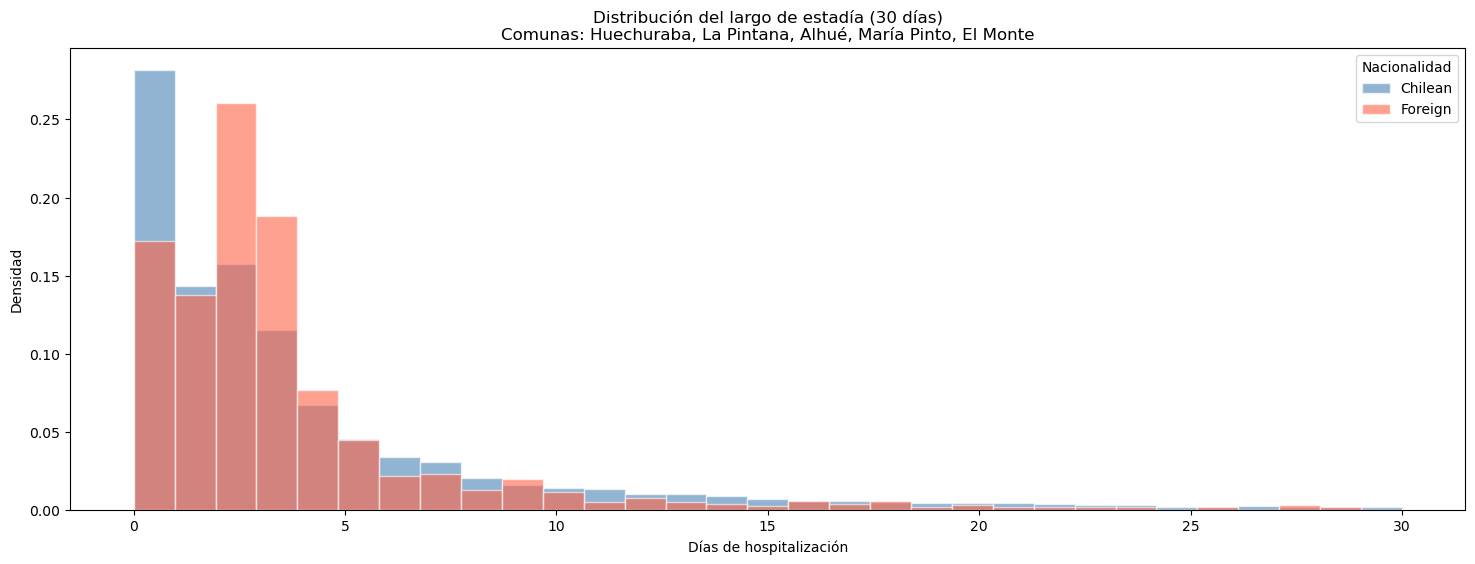

In [52]:
##################################################################
### 🐧🐧**B.2.1 Duración de estadía según nacionalidad*¨*🐧🐧 ####
##################################################################

# density=true para normalizar el histograma a densidad, y así comparar formas de distribución sin importar el número total de egresos en cada grupo de chilenos vs extranjeros

# Tabla resumen
los_resumen = (
    grd_com.groupby("nat_group")["los"] #separamos en 2 grupos
    .agg(mean="mean", median="median", min="min", max="max", n="count") #estadísticas por grupo
    .round(2) #redondea a 2 decimales
)
print("Largo de estadía, en días, por nacionalidad:")
print(los_resumen)

# Gráfico: distribución acotada a 30 días
fig, ax = plt.subplots(figsize=(18, 6))

for grupo, color in zip(["Chilean", "Foreign"], ["steelblue", "tomato"]):
    subset = grd_com[(grd_com["nat_group"] == grupo) & (grd_com["los"] <= 30)]["los"] #limitamos a 30 días
    ax.hist(subset, bins=31, range=(0, 30), alpha=0.6, label=grupo,
            color=color, edgecolor="white", density=True)

# Histograma
ax.set_title("Distribución del largo de estadía (30 días)\nComunas: Huechuraba, La Pintana, Alhué, María Pinto, El Monte", fontsize=12)
ax.set_xlabel("Días de hospitalización")
ax.set_ylabel("Densidad")
ax.legend(title="Nacionalidad")

plt.show()

La mayoría de la estadías, para ambos grupos, se concentran en pocos días, entre 0 y 4 días, con una fuerte asimetría hacia la derecha. 

Los pacientes extranjeros presentan mayor concentración entre los 3 a 5 días, mientras que los chilenos muestran una mayor presencia entre 0 a 1 días, no mostrando así diferencias extremas en relación con otros resultados de la tarea.

---
En esta parte se debe analizar la variable `IR_29301_SEVERIDAD`, que clasifica la severidad clínica del egreso hospitalario.

Los valores corresponden a:

- `0`: sin severidad
- `1`: menor
- `2`: moderada
- `3`: mayor

Se debe representar la distribución de severidad en un gráfico de barras, separando entre población **chilena** y **extranjera**.

Para interpretar correctamente las categorías, se debe consultar la tabla de referencia indicada en `TablasMaestrasBasesGRD.xlsx`, específicamente la hoja **“Severidad GRD”**. 


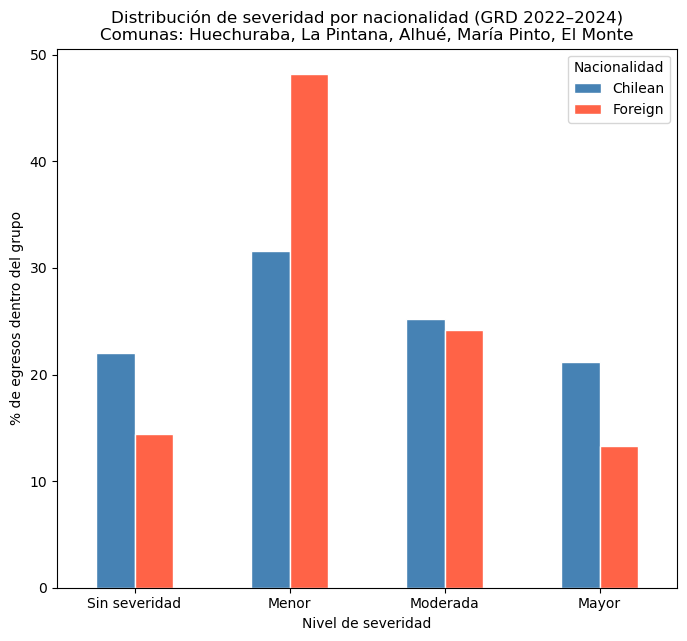


Share de severidad por nacionalidad (%):
nat_group        Chilean  Foreign
severidad_label                  
Sin severidad      22.06    14.41
Menor              31.55    48.16
Moderada           25.24    24.18
Mayor              21.14    13.25


In [53]:
##################################################################
### 🐧🐧**B.2.2 Distribución de severidad*¨*🐧🐧 ####
##################################################################

# Etiquetas 
severidad_labels = {
    0: "Sin severidad",
    1: "Menor",
    2: "Moderada",
    3: "Mayor"
}

# Asegurarse de que la columna es numérica
grd_com["IR_29301_SEVERIDAD"] = pd.to_numeric(grd_com["IR_29301_SEVERIDAD"], errors="coerce")

# Contar por severidad y nacionalidad
sev = (
    grd_com.groupby(["IR_29301_SEVERIDAD", "nat_group"])
    .size()
    .reset_index(name="egresos")
)

# Calcular porcentaje dentro de cada grupo de nacionalidad
sev["share"] = sev.groupby("nat_group")["egresos"].transform(lambda x: x / x.sum() * 100)
sev["severidad_label"] = sev["IR_29301_SEVERIDAD"].map(severidad_labels)

# Pivot y gráfico
sev_pivot = sev.pivot(index="severidad_label", columns="nat_group", values="share").fillna(0)


# Ordenar categorías correctamente
orden = ["Sin severidad", "Menor", "Moderada", "Mayor"]
sev_pivot = sev_pivot.reindex([o for o in orden if o in sev_pivot.index])

fig, ax = plt.subplots(figsize=(8, 7))
sev_pivot.plot(kind="bar", ax=ax, color=["steelblue", "tomato"],
               edgecolor="white", rot=0)

ax.set_title("Distribución de severidad por nacionalidad (GRD 2022–2024)\nComunas: Huechuraba, La Pintana, Alhué, María Pinto, El Monte", fontsize=12)
ax.set_xlabel("Nivel de severidad")
ax.set_ylabel("% de egresos dentro del grupo")
ax.legend(title="Nacionalidad")


plt.show()

print("\nShare de severidad por nacionalidad (%):")
print(sev_pivot.round(2))

Por un lado, la severidad menor concentra la mayor proporción de egresos en ambos grupos, destacando en esta categorían pacientes extranjeros (48,16% vs 31,55% en chilenos), lo que sugiere cuadros clínicos relativamente menos complejos en esta población.  

En cambio, los pacientes chilenos presentan mayores porcentajes en sin severidad, moderada y mayor, destacando una mayor presencia relativa de casos severos (21,14% vs 13,25% extranjeros).

---
En esta sección se debe analizar la variable `TIPOALTA`, que describe el resultado o desenlace del egreso hospitalario. Se debe mostrar la distribución de tipos de egreso, por ejemplo:

- DOMICILIO
- FALLECIDO
- DERIVACION
- entre otros...

Además, se debe calcular la tasa de mortalidad intrahospitalaria, definida como la proporción de egresos en que `TIPOALTA == "FALLECIDO"`. Esta debe calcularse separando entre población **chilena** y **extranjera**, y presentarse en una tabla pequeña.


In [54]:
##################################################################
### 🐧🐧**B.2.3 Tipo de egreso*¨*🐧🐧 ####
##################################################################

# Contar tipos de egresos
print(grd_com["TIPOALTA"].value_counts())

# Tasa de mortalidad intrahospitalaria por nacionalidad
mortalidad = (
    grd_com.groupby("nat_group")
    .apply(lambda x: pd.Series({
        "total_egresos": len(x),
        "fallecidos": (x["TIPOALTA"].str.upper().str.strip() == "FALLECIDO").sum(),
    }))
    .assign(mortality_rate=lambda df: (df["fallecidos"] / df["total_egresos"] * 100).round(3))
)



TIPOALTA
DOMICILIO                                        34336
HOSPITALIZACIÓN DOMICILIARIA                      1553
FALLECIDO                                          864
DERIVACIÓN OTRO HOSPITAL DEL SERVICIO              712
ALTA VOLUNTARIA                                    373
FUGA DEL PACIENTE                                  212
DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS      132
DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL        129
DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE       101
DERIVACIÓN INST. PRIVADA (VOLUNTARIO)               11
Name: count, dtype: int64


In [55]:
# Tasa de mortalidad intrahospitalaria por nacionalidad
mortalidad = (
    grd_com.groupby("nat_group")
    .apply(lambda x: pd.Series({
        "total_egresos": len(x),
        "fallecidos": (x["TIPOALTA"].str.upper().str.strip() == "FALLECIDO").sum(),
    }))
    .assign(mortality_rate=lambda df: (df["fallecidos"] / df["total_egresos"] * 100).round(3))
)

print("Tasa de mortalidad intrahospitalaria por nacionalidad (%):")
print(mortalidad)

Tasa de mortalidad intrahospitalaria por nacionalidad (%):
           total_egresos  fallecidos  mortality_rate
nat_group                                           
Chilean            36959         850           2.300
Foreign             1464          14           0.956


Con lo anterior podemos notar una tasa de mayor mortalidad en chilenos que en extranjeros. Además, solo por curiosidad, buscamos de qué nacionalidad fueron dichas fugas.

In [56]:
# 
# Filtrar fugas del paciente
fugas = grd_com[
    grd_com["TIPOALTA"].str.upper().str.strip() == "FUGA DEL PACIENTE"
]

# Conteo por nacionalidad
fugas_nac = fugas["nat_group"].value_counts().reset_index()
fugas_nac.columns = ["Nacionalidad", "Cantidad"]

# Porcentaje
fugas_nac["Porcentaje"] = (
    fugas_nac["Cantidad"] / fugas_nac["Cantidad"].sum() * 100
).round(2)

print("Fugas del paciente según nacionalidad:")
print(fugas_nac.to_string(index=False))

Fugas del paciente según nacionalidad:
Nacionalidad  Cantidad  Porcentaje
     Chilean       209       98.58
     Foreign         3        1.42


---

### **🐧🐧B.3 Visión espacial (0.5 pts) 🐧🐧**

En esta sección se debe calcular una tasa cruda de hospitalización por comuna, utilizando como numerador el total de egresos hospitalarios y como denominador la población total proveniente de la Tarea 1. La tasa debe expresarse por cada **10.000 habitantes**, siguiendo la lógica explicada en la parte A de esta misma tarea.

Una vez calculada esta tasa, se debe representar espacialmente mediante un mapa coroplético usando `geopandas`. Para ello, es necesario unir la tabla con tasas comunales a la capa geográfica de comunas, de manera que cada territorio quede asociado con su valor de hospitalización.

In [ ]:
#Ayuda con tilde para María Pinto

def limpiar_comuna(x):
    x = str(x).upper().strip()
    x = ''.join(
        c for c in unicodedata.normalize("NFD", x)
        if unicodedata.category(c) != "Mn"
    )
    return x



Tasa de hospitalización por comuna cada 10.000 habitantes:
  nombre_comuna  grd_total  pop_total  grd_rate_per_10k
0    La Pintana      25556     175421            1456.8
1    Huechuraba       6170     101808             606.0
2      El Monte       4114      37497            1097.2
3   María Pinto       1683      15352            1096.3
4         Alhué        900       7768            1158.6


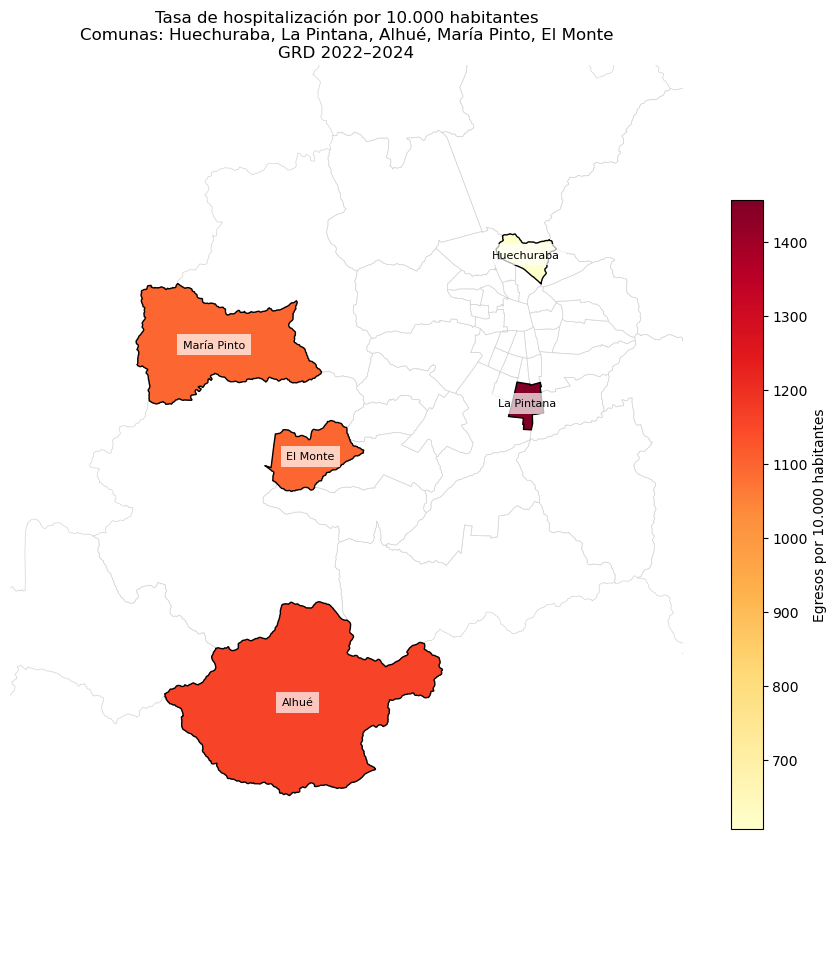

In [58]:
##################################################################
### 🐧🐧 B.3.1 Mapa coroplético: tasa de hospitalización por comuna 🐧🐧 ###
##################################################################

#  Mapear nombre comuna -> código comuna
nombre_a_codigo = {
    limpiar_comuna(row["nombre_comuna"]): row["codigo_comuna"]
    for _, row in my_t1.iterrows()
}

# Contar egresos por comuna
egresos_comuna = grd_com["COMUNA"].value_counts().reset_index()
egresos_comuna.columns = ["COMUNA", "grd_total"]

# Agregar código de comuna
egresos_comuna["codigo_comuna"] = egresos_comuna["COMUNA"].apply(limpiar_comuna).map(nombre_a_codigo)
#  Merge con población
egresos_comuna = egresos_comuna.merge(
    my_t1[["codigo_comuna", "nombre_comuna", "pop_total"]],
    on="codigo_comuna",
    how="left"
)

# 5. Calcular tasa por 10.000 habitantes
egresos_comuna["grd_rate_per_10k"] = (
    egresos_comuna["grd_total"] / egresos_comuna["pop_total"] * 10_000
).round(1)

print("Tasa de hospitalización por comuna cada 10.000 habitantes:")
print(egresos_comuna[["nombre_comuna", "grd_total", "pop_total", "grd_rate_per_10k"]])

# 6. Cargar shapefile
comunas_gdf = gpd.read_file("comunas.shp")

# Asegurar tipo numérico del código de comuna
comunas_gdf["cod_comuna"] = pd.to_numeric(comunas_gdf["cod_comuna"], errors="coerce")

# Filtrar solo Región Metropolitana
# Ajusta este nombre si en tu shapefile la columna de región tiene otro nombre
rm_gdf = comunas_gdf[comunas_gdf["cod_comuna"].astype(str).str.startswith("13")].copy()

#  Merge de tus comunas con tasas
map_sel = rm_gdf.merge(
    egresos_comuna[["codigo_comuna", "grd_rate_per_10k", "nombre_comuna"]],
    left_on="cod_comuna",
    right_on="codigo_comuna",
    how="inner"
)

# Graficar
fig, ax = plt.subplots(figsize=(10, 10))

# Base: todas las comunas RM en gris
rm_gdf.plot(
    ax=ax,
    color="white",
    edgecolor="lightgray",
    linewidth=0.5
)

# Comunas seleccionadas coloreadas por tasa
map_sel.plot(
    column="grd_rate_per_10k",
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"label": "Egresos por 10.000 habitantes", "shrink": 0.7},
    edgecolor="black",
    linewidth=1,
    ax=ax
)

# Zoom a tus comunas
xmin, ymin, xmax, ymax = map_sel.total_bounds
xpad = (xmax - xmin) * 0.3
ypad = (ymax - ymin) * 0.3
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

# Etiquetas
map_sel["centroid"] = map_sel.geometry.centroid
for _, row in map_sel.iterrows():
    ax.text(
        row["centroid"].x,
        row["centroid"].y,
        row["nombre_comuna"],
        fontsize=8,
        ha="center",
        va="center",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

ax.set_title(
    "Tasa de hospitalización por 10.000 habitantes\n"
    "Comunas: Huechuraba, La Pintana, Alhué, María Pinto, El Monte\n"
    "GRD 2022–2024"
)

ax.axis("off")
plt.tight_layout()
plt.show()

---
### **🐧🐧B.4 Tabla resumen GRD a nivel de comuna (0.5 pts) 🐧🐧**




En esta sección se debe construir una **tabla resumen a nivel de comuna** que consolide los principales indicadores obtenidos del análisis de egresos hospitalarios GRD.

Cada fila debe corresponder a una comuna y la tabla debe incluir las siguientes variables:

- **`codigo_comuna`**: código numérico de la comuna  
- **`nombre_comuna`**: nombre de la comuna  
- **`grd_total`**: total de egresos hospitalarios en el período 2022–2024  
- **`grd_chilean`**: egresos de personas chilenas  
- **`grd_foreign`**: egresos de personas extranjeras  
- **`grd_pct_foreign`**: porcentaje de egresos correspondientes a población extranjera  
- **`grd_mean_los`**: duración promedio de estadía hospitalaria  
- **`grd_mean_los_chilean`**: duración promedio de estadía en población chilena  
- **`grd_mean_los_foreign`**: duración promedio de estadía en población extranjera  
- **`grd_mean_severity`**: puntaje promedio de severidad  
- **`grd_mortality_rate`**: tasa de mortalidad intrahospitalaria, calculada como el porcentaje de egresos con `TIPOALTA == "FALLECIDO"`  
- **`grd_top3_chapters`**: tres capítulos CIE-10 más frecuentes en la comuna  
- **`grd_rate_per_10k`**: tasa cruda de hospitalización por cada 10.000 habitantes  

Para calcular `grd_rate_per_10k`, se debe utilizar `pop_total` proveniente del resumen comunal de la Tarea 1.

Dado que en GRD las comunas suelen estar identificadas por nombre, será necesario vincular esos nombres con los códigos de comuna utilizados en la tabla censal, de forma de poder integrar correctamente la información demográfica.

Finalmente, la tabla debe mostrarse en el notebook y guardarse como archivo `.csv`, ya que constituye la salida resumen principal de la Parte B.

In [ ]:
def build_grd_summary(df):
    
    # Totales 
    grd_total   = len(df)
    grd_chilean = (df["nat_group"] == "Chilean").sum()
    grd_foreign = (df["nat_group"] == "Foreign").sum()
    grd_pct_foreign = round(grd_foreign / grd_total * 100, 2) if grd_total > 0 else 0.0

    # grd
    grd_mean_los         = round(df["los"].mean(), 2)
    grd_mean_los_chilean = round(df.loc[df["nat_group"] == "Chilean", "los"].mean(), 2)
    grd_mean_los_foreign = round(df.loc[df["nat_group"] == "Foreign", "los"].mean(), 2)

    # Severidad
    sev_col = "IR_29301_SEVERIDAD"
    grd_mean_severity = round(pd.to_numeric(df[sev_col], errors="coerce").mean(), 2)

    # mortalidad
    fallecidos = (df["TIPOALTA"].str.upper().str.strip() == "FALLECIDO").sum()
    grd_mortality_rate = round(fallecidos / grd_total * 100, 3) if grd_total > 0 else 0.0

    # top 3 ICD-10 chapters 
    top3 = (
        df["Capítulo"]
        .value_counts()
        .head(3)
        .index
        .tolist()
    )
    grd_top3_chapters = ", ".join(top3) #está separado por comas los caítulos, para tener en cuenta en futuras tareas

    return pd.Series({
        "grd_total"           : grd_total,
        "grd_chilean"         : grd_chilean,
        "grd_foreign"         : grd_foreign,
        "grd_pct_foreign"     : grd_pct_foreign,
        "grd_mean_los"        : grd_mean_los,
        "grd_mean_los_chilean": grd_mean_los_chilean,
        "grd_mean_los_foreign": grd_mean_los_foreign,
        "grd_mean_severity"   : grd_mean_severity,
        "grd_mortality_rate"  : grd_mortality_rate,
        "grd_top3_chapters"   : grd_top3_chapters,
    })

In [68]:
# Agregar
grd_summary = grd_com.groupby("COMUNA").apply(build_grd_summary).reset_index()

# Nombre de comuna con codigo_comuna 
# Otra vez el problema de los tildes, aplicamos
grd_summary["codigo_comuna"] = (
    grd_summary["COMUNA"].apply(limpiar_comuna).map(nombre_a_codigo)
)

# Merge con Tarea 1
grd_summary = grd_summary.merge(
    my_t1[["codigo_comuna", "nombre_comuna", "pop_total"]],
    on="codigo_comuna",
    how="left"
)

# dato crudos para 10.000 habitantes
grd_summary["grd_rate_per_10k"] = (
    grd_summary["grd_total"] / grd_summary["pop_total"] * 10_000
).round(1)

# Columnas
cols = [
    "codigo_comuna", "nombre_comuna",
    "grd_total", "grd_chilean", "grd_foreign", "grd_pct_foreign",
    "grd_mean_los", "grd_mean_los_chilean", "grd_mean_los_foreign",
    "grd_mean_severity", "grd_mortality_rate",
    "grd_top3_chapters", "grd_rate_per_10k",
]
grd_summary = grd_summary[cols]

# Guardar 
display(grd_summary)
grd_summary.to_csv("tarea2_grd_summary.csv", index=False)

,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,13502,Alhué,900,793,107,11.89,5.64,5.80,4.46,1.28,2.333,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",1158.6
1,13602,El Monte,4114,4015,99,2.41,5.95,5.98,4.66,1.62,2.552,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",1097.2
2,13107,Huechuraba,6170,5743,427,6.92,6.09,6.22,4.27,1.37,3.420,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",606.0
3,13112,La Pintana,25556,24778,778,3.04,5.37,5.42,3.86,1.47,1.953,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",1456.8
4,13504,María Pinto,1683,1630,53,3.15,4.78,4.83,3.11,1.20,1.664,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",1096.3


In [ ]:
# TOP 3 por comuna (capítulos CIE-10 más frecuentes) debido a que no se ven bien en la tabla, se imprime por separado
for _, row in grd_summary.iterrows():
    print(f"{row['nombre_comuna']}:")
    print(f"  {row['grd_top3_chapters']}")
    print()

Alhué:
  Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A), Cap.11  ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95), Cap.19  LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS CONSECUENCIAS DE CAUSAS EXTERNAS (S00-T88)

El Monte:
  Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A), Cap.11  ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95), Cap.14  ENFERMEDADES DEL APARATO GENITOURINARIO (N00-N99)

Huechuraba:
  Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A), Cap.19  LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS CONSECUENCIAS DE CAUSAS EXTERNAS (S00-T88), Cap.11  ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95)

La Pintana:
  Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A), Cap.11  ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95), Cap.19  LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS CONSECUENCIAS DE CAUSAS EXTERNAS (S00-T88)

María Pinto:
  Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A), Cap.11  ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95), Cap.14  ENFERMEDADES DEL APARATO GENITOURINARIO (N00-N99)

